# Tokenizer Fertility and RankMe: Does Tokenization Efficiency Shape Representation Geometry?

**Author:** Giacomo Porpiglia

---

## Research Question

> **Does tokenizer *fertility* — the average number of subword tokens generated per word — correlate with the RankMe score of the resulting representations? And how does this relationship evolve across layers and training checkpoints?**

Tokenizer **fertility** for language $\ell$ is defined as:

$$\text{fertility}(\ell) = \frac{\sum_{t \in \mathcal{T}_\ell} |\text{tokenize}(t)|}{\sum_{t \in \mathcal{T}_\ell} |\text{words}(t)|}$$

For script-continuous languages (Chinese, Japanese) where word boundaries are absent, $|\text{words}(t)|$ is replaced by $|\text{chars}(t)|$ (non-whitespace characters), so the unit becomes *tokens per character*.

A high-fertility language is one the tokenizer encodes **inefficiently** — it fragments text into many small subword pieces rather than whole morphemes. We investigate whether this fragmentation leaves a measurable signature in the *geometry* of learned representations, as captured by **RankMe** (the effective dimensionality of the activation matrix, measured via Shannon entropy of singular values).

### Hypotheses

| # | Hypothesis | Why it might hold |
|---|------------|-------------------|
| H1 | **Layer-wise signature**: fertility predicts RankMe at the final checkpoint, especially in late layers. | Semantic information is concentrated in later layers; poor tokenization may reduce representational diversity there. |
| H2 | **Depth profile**: the fertility–RankMe correlation changes across depth. | Early layers capture token-level patterns (directly tied to tokenization); later layers capture abstractions. |
| H3 | **Training trajectory**: high- and low-fertility languages follow different RankMe growth curves. | The model may learn efficient representations for low-fertility languages faster/more completely. |


In [1]:
import os
import sys

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

sys.path.insert(0, os.path.join(REPO_ROOT, "code", "visualization"))
sys.path.insert(0, os.path.join(REPO_ROOT, "code", "geometry_analysis"))

In [2]:
# ── CONFIGURATION — only this cell needs to change to switch models ────────────
import yaml

CONFIG_YAML = os.path.join(REPO_ROOT, "code", "geometry_analysis", "configs", "apertus_fine_wiki.yaml")
# ──────────────────────────────────────────────────────────────────────────────

with open(CONFIG_YAML) as f:
    _cfg = yaml.safe_load(f)

TOKENIZER_NAME = _cfg["model"]["name"]
RESULTS_CSV    = os.path.join(REPO_ROOT, "code", _cfg["output"]["results_path"])
MODEL_LABEL    = TOKENIZER_NAME.split("/")[-1]   # e.g. 'Apertus-8B-2509' or 'FuxiTranyu-8B'

DATASET_CONFIGS = {ds["name"]: ds for ds in _cfg["datasets"]}

print(f"Model      : {TOKENIZER_NAME}")
print(f"Results CSV: {RESULTS_CSV}")
print(f"Model label: {MODEL_LABEL}")
print(f"Datasets   : {list(DATASET_CONFIGS.keys())}")

import pathlib as _pl
YAML_STEM  = _pl.Path(CONFIG_YAML).stem          # e.g. 'apertus_wiki'
STATIC_DIR = f'statics_giacomo/{YAML_STEM}'
_pl.Path(STATIC_DIR).mkdir(parents=True, exist_ok=True)
print(f'Statics dir: {STATIC_DIR}')

# Second model for comparison — swap to match which model is primary above
COMPARE_YAML = os.path.join(REPO_ROOT, "code", "geometry_analysis", "configs", "fuxi_fine_wiki.yaml")
# COMPARE_YAML = "../geometry_analysis/configs/apertus_fine_wiki.yaml"
# COMPARE_YAML = None   # set to None to skip all comparison sections

Model      : swiss-ai/Apertus-8B-2509
Results CSV: /scratch/giacomo/open-project-m2-jpmg/code/results/apertus_fine_wiki.csv
Model label: Apertus-8B-2509
Datasets   : ['English', 'Chinese', 'French', 'Indonesian', 'Italian', 'Swahili', 'Spanish', 'German', 'Hindi', 'Arabic', 'Turkish', 'Vietnamese', 'Japanese', 'Finnish']
Statics dir: statics_giacomo/apertus_fine_wiki


In [3]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

## 0. Load Results

The results CSV path is read from the config file above (`output.results_path`).  
If the file does not exist, run the geometry analysis pipeline first:
```
python geometry_analysis/geometry_analysis.py --config <CONFIG_YAML>
```

In [4]:
if not os.path.exists(RESULTS_CSV):
    raise FileNotFoundError(
        f"Results file not found: {RESULTS_CSV}\n"
        f"Generate it by running:\n"
        f"  python geometry_analysis/geometry_analysis.py --config {CONFIG_YAML}"
    )

df = pd.read_csv(RESULTS_CSV)
data_label = MODEL_LABEL

print(f"Loaded {len(df):,} rows | model: {MODEL_LABEL}")
print(f"Checkpoints : {df.checkpoint.nunique()}")
print(f"Languages   : {sorted(df.dataset.unique())}")
print(f"Layers      : {df.layer.nunique()}")
print(f"Aggregations: {df.aggregation.unique().tolist()}")
df.head(3)

Loaded 40,320 rows | model: Apertus-8B-2509
Checkpoints : 45
Languages   : ['Arabic', 'Chinese', 'English', 'Finnish', 'French', 'German', 'Hindi', 'Indonesian', 'Italian', 'Japanese', 'Spanish', 'Swahili', 'Turkish', 'Vietnamese']
Layers      : 32
Aggregations: ['last', 'mean']


,checkpoint,dataset,layer,aggregation,rankme,pr,alpha_req,top_1_var,top_5_var,top_10_var,top_25_var,top_50_var,top_100_var,top_250_var,top_500_var,top_1000_var
0,step50000-tokens210B,English,layer_0,last,5.8682,1.5762,1.188366,0.7962,0.8309,0.8427,0.8605,0.8777,0.8991,0.9328,0.9609,0.9854
1,step50000-tokens210B,English,layer_1,last,7.5185,1.6438,0.806348,0.7798,0.8064,0.8165,0.8329,0.8488,0.8688,0.9022,0.9330,0.9657
2,step50000-tokens210B,English,layer_2,last,9.9573,2.1356,0.731912,0.6738,0.8088,0.8189,0.8340,0.8486,0.8668,0.8981,0.9279,0.9607


In [5]:
def ckpt_key(name):
    """Numeric sort key for checkpoint names: tokens seen, 'main' goes last."""
    if str(name).lower() == "main":
        return float("inf")
    m = re.match(r"step\d+-tokens(\d+)([BT])", str(name), re.IGNORECASE)
    if m:
        val = float(m.group(1))
        return val * 1000 if m.group(2).upper() == "T" else val
    return float("inf") - 1

def layer_num(name):
    m = re.search(r"(\d+)", str(name))
    return int(m.group(1)) if m else 0

def ckpt_label(name):
    """Compact checkpoint label: '210B', '15T', 'main'."""
    if str(name).lower() == "main":
        return "main"
    m = re.match(r"step\d+-tokens(\d+)([BT])", str(name), re.IGNORECASE)
    return f"{m.group(1)}{m.group(2)}" if m else name

checkpoints = sorted(df.checkpoint.unique(), key=ckpt_key)
languages   = sorted(df.dataset.unique())
layers      = sorted(df.layer.unique(), key=layer_num)
layer_nums  = [layer_num(l) for l in layers]
ckpt_labels = [ckpt_label(c) for c in checkpoints]

# Use last-token aggregation throughout (causal LM prediction target)
df_last = df[df.aggregation == "last"].copy()

print(f"Checkpoints : {checkpoints[0]} … {checkpoints[-1]}  ({len(checkpoints)} total)")
print(f"Layers      : layer_{layer_nums[0]} … layer_{layer_nums[-1]}  ({len(layers)} total)")

Checkpoints : step50000-tokens210B … main  (45 total)
Layers      : layer_0 … layer_31  (32 total)


In [6]:
# Load comparison model data (gracefully skipped if COMPARE_YAML is None or CSV missing)
import pathlib as _pl2, json as _json2

# Sentinels — all comparison cells guard on df2
df2                   = None
common_langs2         = []
vocab_coverage_pct2   = {}
vocab_coverage_count2 = {}

if COMPARE_YAML is not None:
    with open(COMPARE_YAML) as _f2:
        _cfg2 = yaml.safe_load(_f2)

    COMPARE_TOKENIZER = _cfg2["model"]["name"]
    COMPARE_CSV       = "../" + _cfg2["output"]["results_path"]
    COMPARE_LABEL     = COMPARE_TOKENIZER.split("/")[-1]
    COMPARE_DATASET   = _cfg2["datasets"][0].get("path", "")

    if not os.path.exists(COMPARE_CSV):
        print(f"WARNING: {COMPARE_CSV} not found — comparison sections skipped.")
    else:
        df2       = pd.read_csv(COMPARE_CSV)
        df2_last  = df2[df2.aggregation == "last"].copy()

        checkpoints2 = sorted(df2.checkpoint.unique(), key=ckpt_key)
        languages2   = sorted(df2.dataset.unique())
        layers2      = sorted(df2.layer.unique(), key=layer_num)
        layer_nums2  = [layer_num(l) for l in layers2]
        ckpt_labels2 = [ckpt_label(c) for c in checkpoints2]
        FINAL_CKPT2  = "main" if "main" in checkpoints2 else checkpoints2[-1]
        df2_final    = df2_last[df2_last.checkpoint == FINAL_CKPT2]

        _fert_path2 = _pl2.Path(f"../results/fertility_{COMPARE_LABEL}.json")
        if _fert_path2.exists():
            _fd2                  = _json2.loads(_fert_path2.read_text())
            fertility2            = _fd2["fertility"]
            fert_unit2            = _fd2.get("unit", {})
            vocab_coverage_pct2   = _fd2.get("vocab_coverage_pct", {})
            vocab_coverage_count2 = _fd2.get("vocab_coverage_count", {})
            print(f"Loaded fertility + coverage for {COMPARE_LABEL}")
        else:
            fertility2 = {}; fert_unit2 = {}
            print(f"WARNING: no fertility JSON for {COMPARE_LABEL} — correlation comparison skipped.")

        common_both   = sorted(set(languages) & set(languages2))
        common_langs2 = [l for l in fertility2 if l in languages2]

        print(f"Primary    : {MODEL_LABEL}  ({len(checkpoints)} ckpts, {len(layers)} layers)")
        print(f"Comparison : {COMPARE_LABEL}  ({len(checkpoints2)} ckpts, {len(layers2)} layers)")
        print(f"Common langs: {common_both}")
        print(f"Dataset note: {COMPARE_DATASET.split('/')[-1]} vs. primary.")


Loaded fertility + coverage for FuxiTranyu-8B
Primary    : Apertus-8B-2509  (45 ckpts, 32 layers)
Comparison : FuxiTranyu-8B  (58 ckpts, 30 layers)
Common langs: ['Arabic', 'Chinese', 'English', 'Finnish', 'French', 'German', 'Hindi', 'Indonesian', 'Italian', 'Japanese', 'Spanish', 'Swahili', 'Turkish', 'Vietnamese']
Dataset note: finewiki vs. primary.


## 1. Tokenizer Fertility

We load the model's tokenizer (as specified in the config) and sample Wikipedia articles for each language to measure how many subword tokens are generated per word (or per character for Chinese and Japanese).
Japanese and Chinese are edge cases, as these languages follow very different rules at the lexical level than others. Therefore, we show results including and excluding these two languages, as their unique natre might interfere with the observation of certain correlations.

> **Why Wikipedia?** Wikipedia provides encyclopedic, formally written text across languages. Using the same domain for both fertility computation and RankMe analysis ensures the measurements are directly comparable.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
#  Fertility + vocabulary coverage.
#  Loads from JSON if already saved; computes and saves otherwise.
#  Delete a model's JSON under results/ to force a fresh computation.
#  Requires (only when computing): transformers, datasets, internet access.
# ─────────────────────────────────────────────────────────────────────────────
N_ARTICLES = 5000    # articles sampled per language (only used when computing)

import pathlib as _pl, json as _json

def _compute_fertility(tokenizer_name, dataset_configs, lang_list, out_path):
    from transformers import AutoTokenizer
    from datasets import load_dataset

    CJK = {'Chinese', 'Japanese'}
    subsets = {name: ds for name, ds in dataset_configs.items() if name in lang_list}

    print(f'  Loading tokenizer: {tokenizer_name}')
    tok = AutoTokenizer.from_pretrained(tokenizer_name, trust_remote_code=True)
    print(f'  Vocab size: {tok.vocab_size:,}')

    fert, unit, cov_pct, cov_cnt = {}, {}, {}, {}
    for lang, ds_cfg in subsets.items():
        print(f'    {lang}...', end=' ', flush=True)
        ds = load_dataset(ds_cfg['path'], ds_cfg['subset'],
                          split=ds_cfg.get('split', 'train'), streaming=True)
        texts = [item['text'] for _, item in zip(range(N_ARTICLES), ds)]

        tok_total, unit_total = 0, 0
        all_ids = set()
        for text in texts:
            text = text.strip()
            if not text:
                continue
            ids = tok.encode(text, add_special_tokens=False)
            tok_total += len(ids)
            all_ids.update(ids)
            if lang in CJK:
                unit_total += len(''.join(text.split()))
            else:
                unit_total += len(text.split())

        u = 'tok/char' if lang in CJK else 'tok/word'
        f = tok_total / unit_total if unit_total else float('nan')
        c = round(100 * len(all_ids) / tok.vocab_size, 2)
        fert[lang] = round(f, 4); unit[lang] = u
        cov_cnt[lang] = len(all_ids); cov_pct[lang] = c
        print(f'{f:.3f} {u}  |  coverage {c:.1f}%')

    out_path.write_text(_json.dumps({
        'model': tokenizer_name, 'fertility': fert, 'unit': unit,
        'vocab_coverage_pct': cov_pct, 'vocab_coverage_count': cov_cnt,
    }, indent=2))
    print(f'  Saved → {out_path}')
    return fert, unit, cov_pct, cov_cnt

def _load_or_compute(tokenizer_name, label, dataset_configs, lang_list):
    path = _pl.Path(f'../results/fertility_{label}.json')
    if path.exists():
        print(f'[{label}] Loading from {path.name}')
        d = _json.loads(path.read_text())
        return (d['fertility'], d.get('unit', {}),
                d.get('vocab_coverage_pct', {}), d.get('vocab_coverage_count', {}))
    print(f'[{label}] JSON not found — computing ({N_ARTICLES} articles/language)...')
    return _compute_fertility(tokenizer_name, dataset_configs, lang_list, path)

# ── Primary model ─────────────────────────────────────────────────────────────
fertility, fert_unit, vocab_coverage_pct, vocab_coverage_count = _load_or_compute(
    TOKENIZER_NAME, MODEL_LABEL, DATASET_CONFIGS, languages)

# ── Comparison model ──────────────────────────────────────────────────────────
if df2 is not None:
    _ds_cfgs2 = {ds['name']: ds for ds in _cfg2['datasets']}
    fertility2, fert_unit2, vocab_coverage_pct2, vocab_coverage_count2 = _load_or_compute(
        COMPARE_TOKENIZER, COMPARE_LABEL, _ds_cfgs2, languages2)
    common_langs2 = [l for l in fertility2 if l in languages2]
else:
    print('No comparison model loaded — skipping.')

[Apertus-8B-2509] Loading from fertility_Apertus-8B-2509.json
[FuxiTranyu-8B] Loading from fertility_FuxiTranyu-8B.json


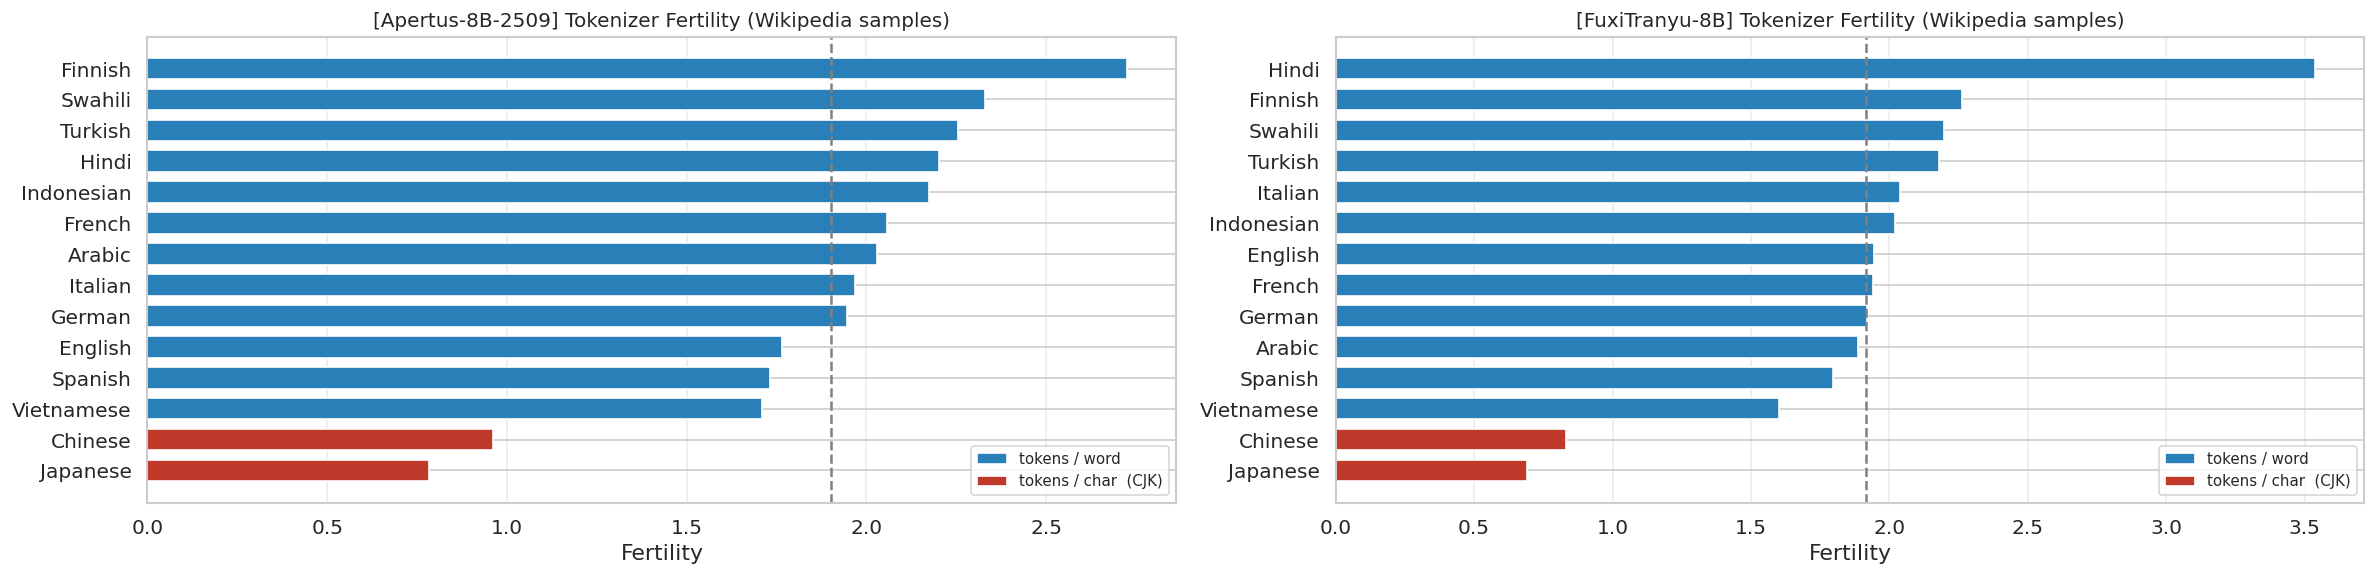

Apertus-8B-2509 fertility values: 
---------------
  language  fertility     unit
  Japanese     0.7839 tok/char
   Chinese     0.9609 tok/char
Vietnamese     1.7096 tok/word
   Spanish     1.7325 tok/word
   English     1.7654 tok/word
    German     1.9460 tok/word
   Italian     1.9671 tok/word
    Arabic     2.0286 tok/word
    French     2.0584 tok/word
Indonesian     2.1756 tok/word
     Hindi     2.2016 tok/word
   Turkish     2.2557 tok/word
   Swahili     2.3293 tok/word
   Finnish     2.7262 tok/word


FuxiTranyu-8B fertility values: 
---------------
  language  fertility     unit
  Japanese     0.6909 tok/char
   Chinese     0.8308 tok/char
Vietnamese     1.5999 tok/word
   Spanish     1.7966 tok/word
    Arabic     1.8860 tok/word
    German     1.9194 tok/word
    French     1.9415 tok/word
   English     1.9431 tok/word
Indonesian     2.0209 tok/word
   Italian     2.0374 tok/word
   Turkish     2.1778 tok/word
   Swahili     2.1969 tok/word
   Finnish     2.2602 tok/word

In [8]:
df_fert = (
    pd.DataFrame({
        "language":  list(fertility.keys()),
        "fertility": list(fertility.values()),
        "unit":      [fert_unit[l] for l in fertility],
    })
    .sort_values("fertility").reset_index(drop=True)
)
common_langs = [l for l in df_fert.language if l in languages]

df_fert2 = None
if df2 is not None and fertility2:
    df_fert2 = (
        pd.DataFrame({
            "language":  list(fertility2.keys()),
            "fertility": list(fertility2.values()),
            "unit":      [fert_unit2.get(l, "tok/word") for l in fertility2],
        })
        .sort_values("fertility").reset_index(drop=True)
    )

plots = [(MODEL_LABEL, df_fert, fert_unit)]
if df_fert2 is not None:
    plots.append((COMPARE_LABEL, df_fert2, fert_unit2))

fig, axes = plt.subplots(1, len(plots), figsize=(10 * len(plots), 5))
axes = [axes] if len(plots) == 1 else list(axes)

for ax, (label, df_f, fert_u) in zip(axes, plots):
    colors = ["#c0392b" if fert_u.get(lang) == "tok/char" else "#2980b9" for lang in df_f.language]
    ax.barh(df_f.language, df_f.fertility, color=colors, height=0.7, edgecolor="white")
    ax.axvline(df_f.fertility.mean(), ls="--", color="gray", lw=1.5,
               label=f"Mean = {df_f.fertility.mean():.2f}")
    ax.set_xlabel("Fertility")
    ax.set_title(f"[{label}] Tokenizer Fertility (Wikipedia samples)", fontsize=12)
    ax.legend(handles=[
        Patch(facecolor="#2980b9", label="tokens / word"),
        Patch(facecolor="#c0392b", label="tokens / char  (CJK)"),
    ], loc="lower right", fontsize=9)
    ax.grid(axis="x", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{STATIC_DIR}/fertility_bar_{MODEL_LABEL}.pdf", bbox_inches="tight")
plt.show()
print(f"{MODEL_LABEL} fertility values: ")
print("---------------")
print(df_fert.to_string(index=False))
print(f"\n\n{COMPARE_LABEL} fertility values: ")
print("---------------")
print(df_fert2.to_string(index=False))

### 1b. Vocabulary Coverage

For each language we count how many **distinct token IDs** appear across the N sampled Wikipedia articles — i.e. what fraction of the full vocabulary the language actually activates.

- A **high-coverage** language touches many corners of the token space, suggesting broad lexical variety or a rich character combination space.
- A **low-coverage** language reuses a small, concentrated token subset — possibly because the tokenizer is well-matched to it (e.g. English) or because its writing system uses a small character set.

Coverage and fertility are complementary measurements:
- **Fertility** measures *density*: tokens per word — how fragmented encoding is for each text fragment.
- **Coverage** measures *breadth*: which tokens are used — how diverse the token distribution is across the corpus sample.
This is supported by their near-zero correlation, showing how these two metrics offer two different ways to study tokenization-related problems.

> **Note:** Coverage values require `COMPUTE=True` in the cluster cell above. The chart below will be empty if that block has not been run.

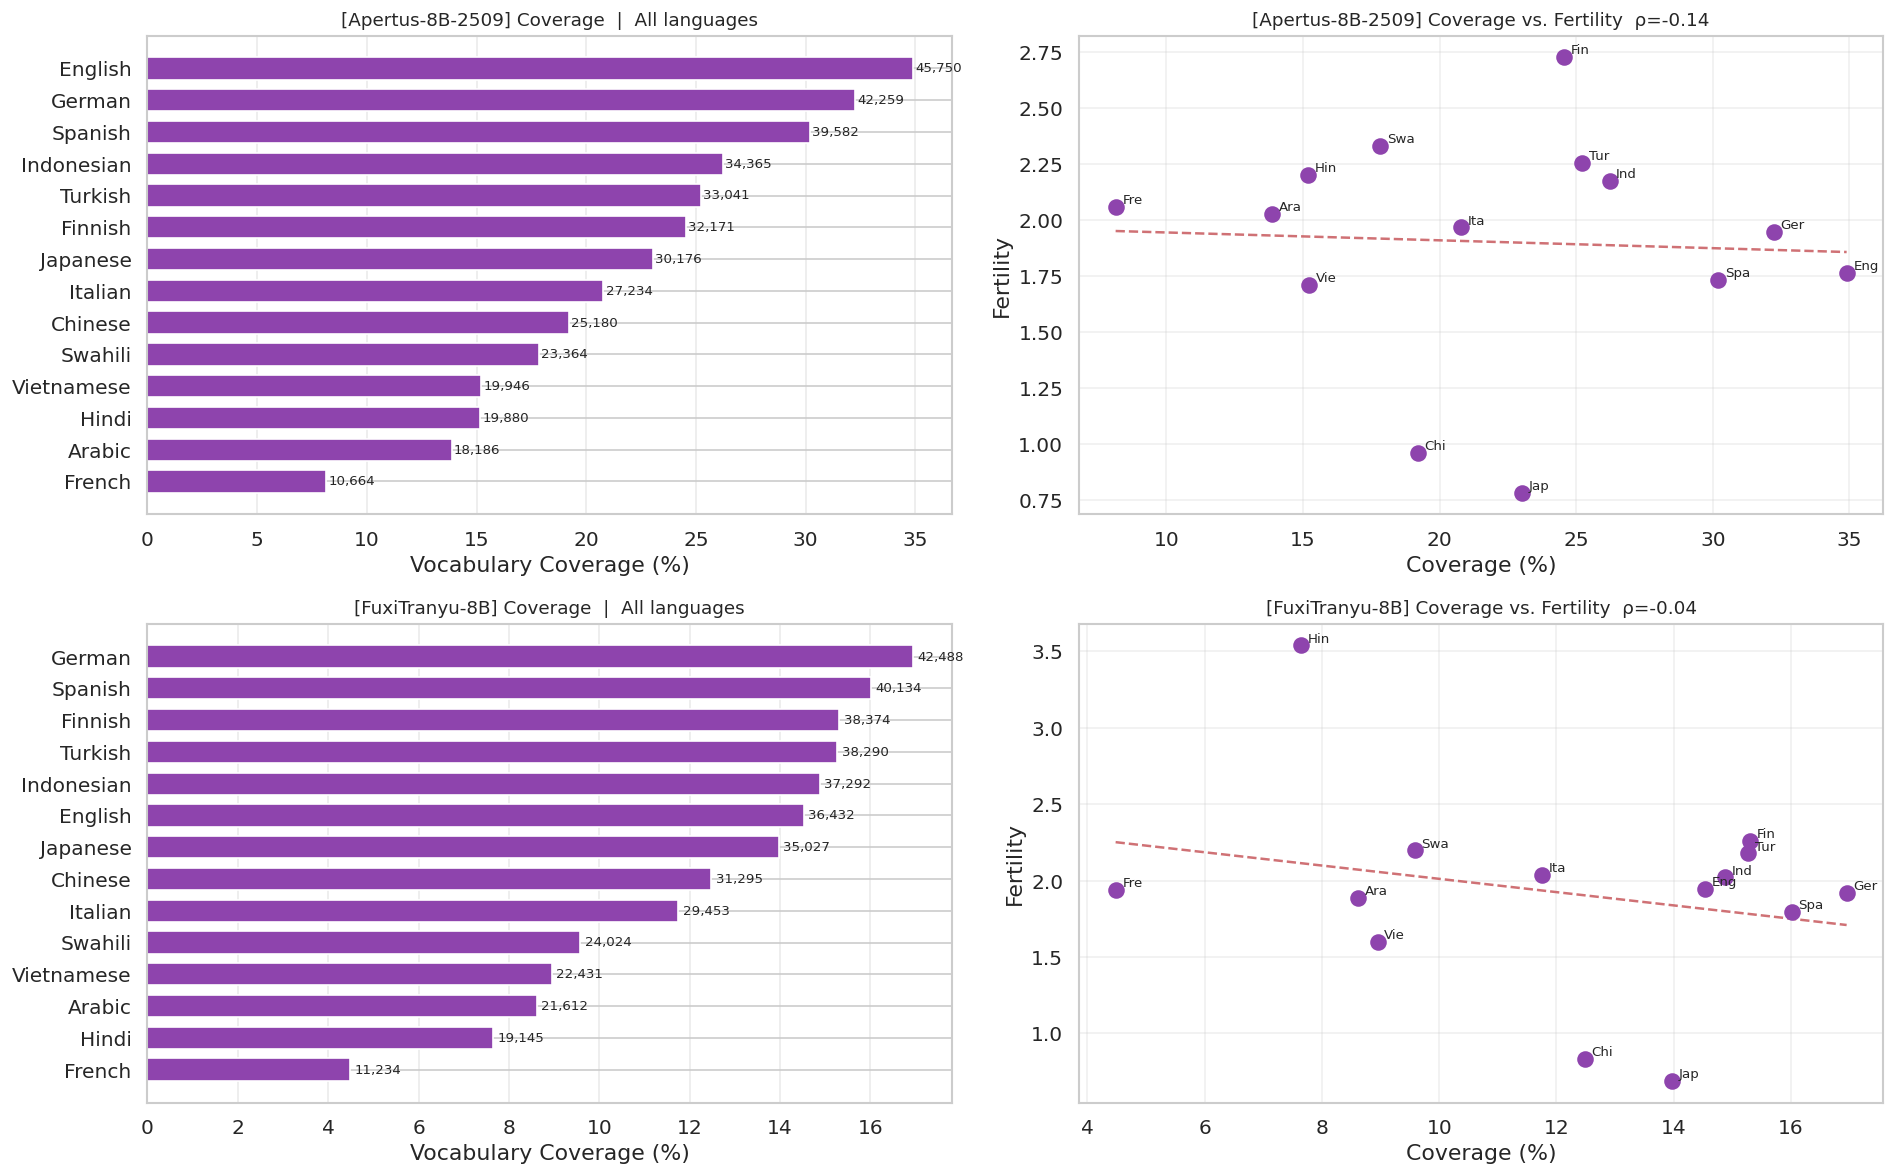

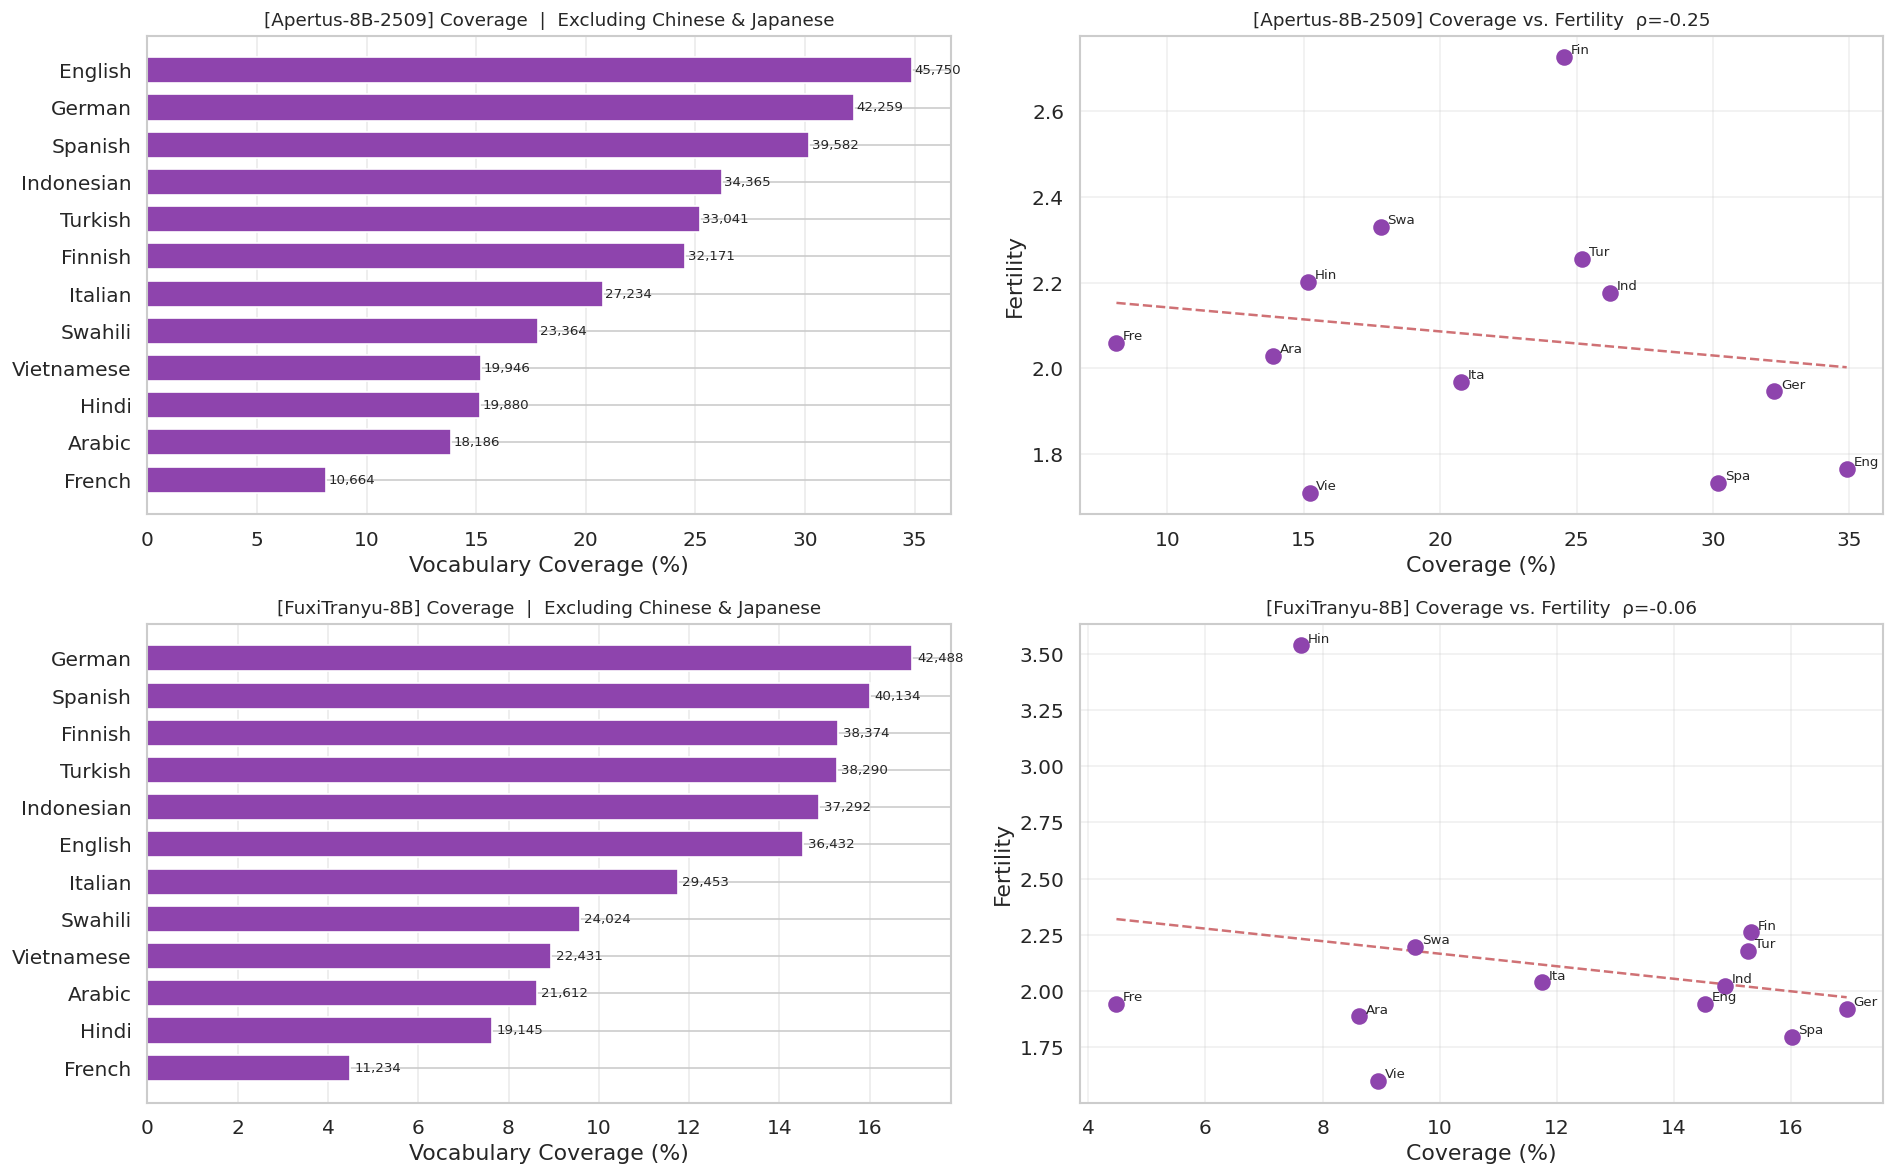

Apertus-8B-2509 coverage values: 
---------------
  language  coverage_pct  coverage_count
    French          8.14           10664
    Arabic         13.87           18186
     Hindi         15.17           19880
Vietnamese         15.22           19946
   Swahili         17.83           23364
   Chinese         19.21           25180
   Italian         20.78           27234
  Japanese         23.02           30176
   Finnish         24.54           32171
   Turkish         25.21           33041
Indonesian         26.22           34365
   Spanish         30.20           39582
    German         32.24           42259
   English         34.90           45750


FuxiTranyu-8B coverage values: 
---------------
  language  coverage_pct  coverage_count
    French          4.48           11234
     Hindi          7.64           19145
    Arabic          8.62           21612
Vietnamese          8.95           22431
   Swahili          9.58           24024
   Italian         11.75           2945

In [9]:
if not vocab_coverage_pct:
    print("No coverage data — run COMPUTE block with COMPUTE=True.")
else:
    cov_df = (
        pd.DataFrame({
            "language":       list(vocab_coverage_pct.keys()),
            "coverage_pct":   list(vocab_coverage_pct.values()),
            "coverage_count": [vocab_coverage_count[l] for l in vocab_coverage_pct],
        })
        .sort_values("coverage_pct").reset_index(drop=True)
    )
    has_cmp = df2 is not None and bool(vocab_coverage_pct2)
    if has_cmp:
        cov_df2 = (
            pd.DataFrame({
                "language":       list(vocab_coverage_pct2.keys()),
                "coverage_pct":   list(vocab_coverage_pct2.values()),
                "coverage_count": [vocab_coverage_count2[l] for l in vocab_coverage_pct2],
            })
            .sort_values("coverage_pct").reset_index(drop=True)
        )

    CJK_LANGS = {"Chinese", "Japanese"}
    for subset_label, excl, suffix in [
        ("All languages",                set(),      "_all"),
        ("Excluding Chinese & Japanese", CJK_LANGS,  "_no_cjk"),
    ]:
        rows_data = [(MODEL_LABEL, cov_df, fertility, fert_unit, vocab_coverage_pct)]
        if has_cmp:
            rows_data.append((COMPARE_LABEL, cov_df2, fertility2, fert_unit2, vocab_coverage_pct2))

        fig, axes = plt.subplots(len(rows_data), 2, figsize=(16, 5 * len(rows_data)))
        axes = axes.reshape(len(rows_data), 2)

        for row, (label, cov_d, fert, fert_u, cov_pct) in enumerate(rows_data):
            sub = cov_d[~cov_d.language.isin(excl)].reset_index(drop=True)
            ax = axes[row, 0]
            ax.barh(sub.language, sub.coverage_pct, color="#8e44ad", height=0.7, edgecolor="white")
            ax.set_xlabel("Vocabulary Coverage (%)")
            ax.set_title(f"[{label}] Coverage  |  {subset_label}", fontsize=11)
            ax.grid(axis="x", alpha=0.4)
            for i, r in sub.iterrows():
                ax.text(r.coverage_pct + 0.1, i, f"{int(r.coverage_count):,}", va="center", fontsize=8)

            ax = axes[row, 1]
            cov_langs = [l for l in cov_pct if l in fert and l not in excl]
            xs = np.array([cov_pct[l] for l in cov_langs])
            ys = np.array([fert[l]     for l in cov_langs])
            ax.scatter(xs, ys, s=80, color="#8e44ad", zorder=3)
            for x, y, lab in zip(xs, ys, cov_langs):
                ax.annotate(lab[:3], (x, y), xytext=(4, 2), textcoords="offset points", fontsize=8)
            if len(xs) >= 3:
                z = np.polyfit(xs, ys, 1)
                xfit = np.linspace(xs.min(), xs.max(), 80)
                ax.plot(xfit, np.polyval(z, xfit), "r--", lw=1.5, alpha=0.8)
                rho_cf, _ = spearmanr(xs, ys)
                ax.set_title(f"[{label}] Coverage vs. Fertility  ρ={rho_cf:.2f}", fontsize=11)
            ax.set_xlabel("Coverage (%)"); ax.set_ylabel("Fertility")
            ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig(f"{STATIC_DIR}/vocab_coverage_{MODEL_LABEL}{suffix}.pdf", bbox_inches="tight")
        plt.show()
    
    print(f"{MODEL_LABEL} coverage values: ")
    print("---------------")
    print(cov_df.to_string(index=False))
    print(f"\n\n{COMPARE_LABEL} coverage values: ")
    print("---------------")
    print(cov_df2.to_string(index=False))

## Observations

For both models, we don't obeserve a strict correlation between fertility and vocabulary coverage, indicating that the amount of different tokens used by a language isn't correlated with fertility. This motivates the use of both metrics to investigate the existence of correlations between RankMe and tokenizers.

### 1c. Training Data Distribution (Fuxi) — Correlation with Vocabulary Coverage and RankMe

FuxiTranyu-8B was trained on a corpus with a known per-language composition. Here we ask whether that composition predicts:

1. **Vocabulary coverage** — does a language with a larger training share activate more of Fuxi's token vocabulary?
2. **RankMe** — does representation geometry at the final checkpoint track training data volume?

Both Pearson $r$ (linear) and Spearman $\rho$ (rank-based, more robust to outliers) are reported. Gold bands in the correlation profile mark layers where Pearson $p < 0.05$.

For Apertus, we don't have the full training language distribution, therefore this study is not applicable.

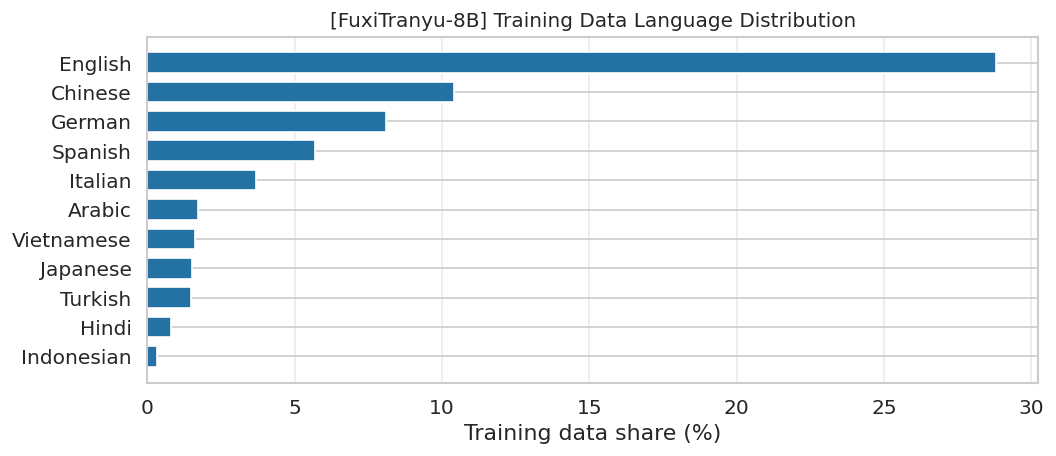

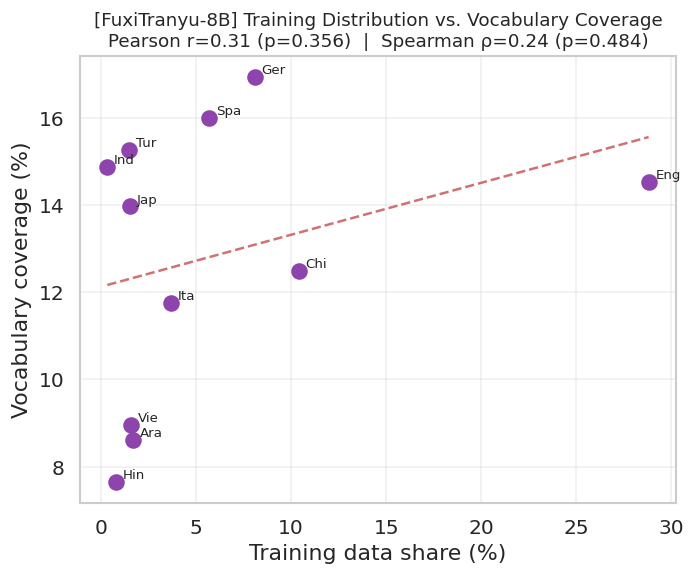

Training dist vs. coverage (FuxiTranyu-8B):  Pearson r=0.309 (p=0.356),  Spearman ρ=0.236 (p=0.484)


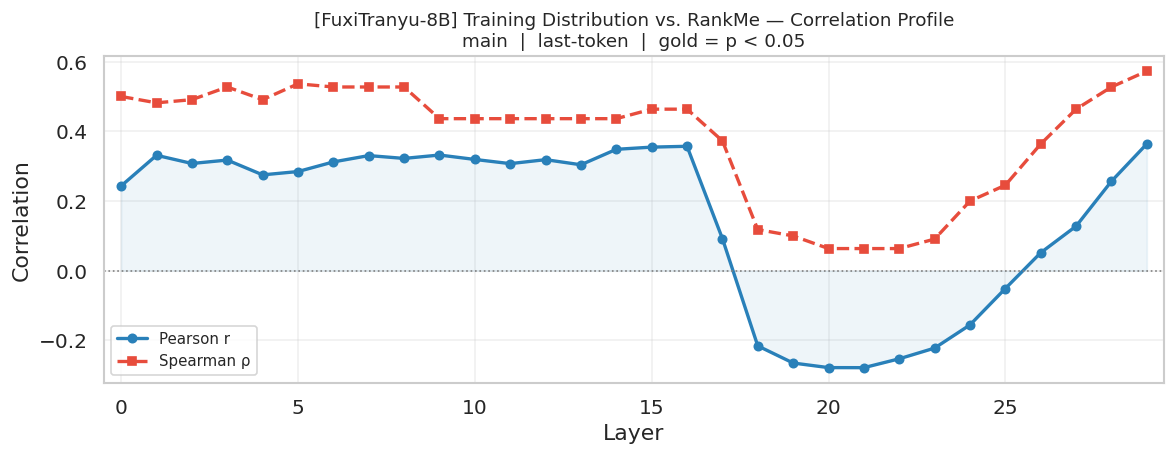


Layers |r| > 0.5 (FuxiTranyu-8B, training dist vs. RankMe):
  (none)


In [10]:
# Training data language distribution for FuxiTranyu-8B for the selected langauges.
# Keys must match dataset language names; values are the share (%) in the training corpus.
# Languages absent from this dict are silently excluded from the analysis.
FUXI_TRAIN_DIST = {
    "Chinese":    10.4,
    "English":    28.8,
    "German":     8.1,
    "Spanish":    5.7,
    "Italian":    3.7,
    "Indonesian": 0.33,
    "Arabic":     1.7,
    "Hindi":      0.79,
    "Turkish":    1.49,
    "Vietnamese": 1.6,
    "Japanese":   1.5,
}

if not FUXI_TRAIN_DIST:
    print("FUXI_TRAIN_DIST is empty — fill in training-data percentages to run this section.")
else:
    dist_langs = sorted(FUXI_TRAIN_DIST.keys())
    dist_vals  = np.array([FUXI_TRAIN_DIST[l] for l in dist_langs])

    # ── 1) Bar chart of training distribution ───────────────────────────────
    sort_idx = np.argsort(dist_vals)
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh([dist_langs[i] for i in sort_idx], dist_vals[sort_idx],
            color="#2471a3", height=0.7, edgecolor="white")
    ax.set_xlabel("Training data share (%)")
    ax.set_title(f"[{COMPARE_LABEL}] Training Data Language Distribution", fontsize=12)
    ax.grid(axis="x", alpha=0.4)
    plt.tight_layout()
    plt.savefig(f"{STATIC_DIR}/train_dist_{COMPARE_LABEL}.pdf", bbox_inches="tight")
    plt.show()

    # ── 2) Training distribution vs. Vocabulary Coverage ────────────────────
    if not vocab_coverage_pct2:
        print("No vocabulary coverage data for Fuxi — run COMPUTE block for the comparison model.")
    else:
        cov_common = [l for l in dist_langs if l in vocab_coverage_pct2]
        if len(cov_common) < 3:
            print(f"Only {len(cov_common)} overlapping languages — skipping coverage correlation.")
        else:
            xs_d = np.array([FUXI_TRAIN_DIST[l]    for l in cov_common])
            ys_c = np.array([vocab_coverage_pct2[l] for l in cov_common])
            r_cov,   p_cov   = pearsonr(xs_d, ys_c)
            rho_cov, p_rho_c = spearmanr(xs_d, ys_c)

            fig, ax = plt.subplots(figsize=(6, 5))
            ax.scatter(xs_d, ys_c, s=80, color="#8e44ad", zorder=3)
            for x, y, lab in zip(xs_d, ys_c, cov_common):
                ax.annotate(lab[:3], (x, y), xytext=(4, 2), textcoords="offset points", fontsize=8)
            z    = np.polyfit(xs_d, ys_c, 1)
            xfit = np.linspace(xs_d.min(), xs_d.max(), 80)
            ax.plot(xfit, np.polyval(z, xfit), "r--", lw=1.5, alpha=0.8)
            ax.set_xlabel("Training data share (%)")
            ax.set_ylabel("Vocabulary coverage (%)")
            ax.set_title(
                f"[{COMPARE_LABEL}] Training Distribution vs. Vocabulary Coverage\n"
                f"Pearson r={r_cov:.2f} (p={p_cov:.3f})  |  Spearman ρ={rho_cov:.2f} (p={p_rho_c:.3f})",
                fontsize=11)
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig(f"{STATIC_DIR}/train_dist_vs_coverage_{COMPARE_LABEL}.pdf", bbox_inches="tight")
            plt.show()
            print(f"Training dist vs. coverage ({COMPARE_LABEL}):  "
                  f"Pearson r={r_cov:.3f} (p={p_cov:.3f}),  Spearman ρ={rho_cov:.3f} (p={p_rho_c:.3f})")

    # ── 3) Training distribution vs. RankMe — correlation profile ───────────
    if df2 is None:
        print(f"Comparison model ({COMPARE_LABEL}) not loaded — skipping RankMe correlation.")
    else:
        prs_dist, rhos_dist, pvals_dist = [], [], []
        for layer in layers2:
            sub      = df2_final[df2_final.layer == layer]
            xs_d, ys_r = [], []
            for lang in dist_langs:
                row = sub[sub.dataset == lang]
                if not row.empty:
                    xs_d.append(FUXI_TRAIN_DIST[lang])
                    ys_r.append(row.rankme.values[0])
            if len(xs_d) < 3:
                prs_dist.append(np.nan); rhos_dist.append(np.nan); pvals_dist.append(np.nan)
                continue
            r_val,   p_val = pearsonr(xs_d, ys_r)
            rho_val, _     = spearmanr(xs_d, ys_r)
            prs_dist.append(r_val); rhos_dist.append(rho_val); pvals_dist.append(p_val)

        fig, ax = plt.subplots(figsize=(10, 4))
        ax.plot(layer_nums2, prs_dist,  "o-",  color="#2980b9", lw=2, ms=5, label="Pearson r")
        ax.plot(layer_nums2, rhos_dist, "s--", color="#e74c3c", lw=2, ms=5, label="Spearman ρ")
        ax.axhline(0, color="gray", lw=1, ls=":")
        ax.fill_between(layer_nums2, prs_dist, 0, alpha=0.08, color="#2980b9")
        sig_added = False
        for lnum, p in zip(layer_nums2, pvals_dist):
            if p is not None and not np.isnan(p) and p < 0.05:
                ax.axvspan(lnum - 0.45, lnum + 0.45, alpha=0.18, color="gold", zorder=0,
                           label="p<0.05" if not sig_added else None)
                sig_added = True
        ax.set_xlabel("Layer")
        ax.set_ylabel("Correlation")
        ax.set_title(
            f"[{COMPARE_LABEL}] Training Distribution vs. RankMe — Correlation Profile\n"
            f"{FINAL_CKPT2}  |  last-token  |  gold = p < 0.05",
            fontsize=11)
        ax.set_xlim(-0.5, layer_nums2[-1] + 0.5)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{STATIC_DIR}/train_dist_vs_rankme_corr_{COMPARE_LABEL}.pdf", bbox_inches="tight")
        plt.show()

        df_dist_corr = pd.DataFrame({
            "layer":        layer_nums2,
            "pearson_r":    prs_dist,
            "spearman_rho": rhos_dist,
            "p_value":      pvals_dist,
        })
        print(f"\nLayers |r| > 0.5 ({COMPARE_LABEL}, training dist vs. RankMe):")
        sig = df_dist_corr[df_dist_corr.pearson_r.abs() > 0.5]
        print(sig.to_string(index=False) if not sig.empty else "  (none)")

## Observations

We observe a positive correlation between training data share and vocabulary coverage, indicating that on average more tokens in the tokenization process are allocated for languages that are more frequent in the training corpus. However, the correlation is not statistically significant, so we can't derive conclusions. <br/>
We then analyse the correlation between training data share and RankMe. We observe a curious change of trend around layer 17, where the correlation becomes suddenly negative. On the last layers, the correlation becomes positive again. Despite not having statistical significance and despite these processes being often governed by obscure factors, one may conclude that the correlation is positive on layers that are close to the vocabulary space (at the extremes of the model), while in the middle, where representations become more abstract, the correlation becomes negative. If this observation was to hold for more languages and become statistically significant, one could conclude that unrepresented languages are more compressed in the middle layers of the model and less compressed in the extreme layers instead.

## 2. RankMe at the Final Checkpoint

We examine the RankMe layer profile for each language at the final training checkpoint (`main`), using the **last-token** aggregation.

Lines are first colored by **fertility** (low = bright, high = dark) and then by **vocabulary coverage** (low = dark, high = bright), so visual clusters in both plots immediately reveal whether either tokenization property tracks RankMe level.

In [ ]:
FINAL_CKPT = "main" if "main" in checkpoints else checkpoints[-1]
df_final = df_last[df_last.checkpoint == FINAL_CKPT]

plots = [(MODEL_LABEL, df_final, fertility, fert_unit, layers, layer_nums, common_langs, FINAL_CKPT)]
if df2 is not None:
    plots.append((COMPARE_LABEL, df2_final, fertility2, fert_unit2, layers2, layer_nums2, common_langs2, FINAL_CKPT2))

# ── Fertility-colored ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(plots), figsize=(12 * len(plots), 5))
axes = [axes] if len(plots) == 1 else list(axes)

for ax, (label, df_fin, fert, fert_u, lyrs, lnums, c_langs, final_ckpt) in zip(axes, plots):
    c_langs_f = [l for l in c_langs if l in fert]
    if not c_langs_f:
        ax.set_title(f"[{label}](no fertility data)"); continue
    fvals = [fert[l] for l in c_langs_f]
    fmin, fmax = min(fvals), max(fvals)
    cmap = plt.cm.plasma_r
    for lang in sorted(c_langs_f, key=lambda l: fert[l]):
        sub = df_fin[df_fin.dataset == lang].sort_values("layer", key=lambda s: s.map(layer_num))
        if sub.empty: continue
        f = fert[lang]
        ax.plot(sub.layer.map(layer_num), sub.rankme, marker="o", ms=4, lw=1.8,
                color=cmap((f - fmin) / (fmax - fmin + 1e-9)),
                label=f"{lang}  [{f:.2f} {fert_u.get(lang, '')}]")
    ax.set_xlabel("Layer"); ax.set_ylabel("RankMe")
    ax.set_title(f"[{label}] RankMe Layer Profiles\n{final_ckpt}  |  last-token", fontsize=11)
    ax.legend(title="Language (fertility)", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("color: low fertility (bright) → high fertility (dark)", fontsize=11)
plt.tight_layout()
plt.savefig(f"{STATIC_DIR}/layer_profiles_{MODEL_LABEL}.pdf", bbox_inches="tight")
plt.show()

# ── Coverage-colored ──────────────────────────────────────────────────────────
if vocab_coverage_pct:
    cov_plots = [(MODEL_LABEL, df_final, vocab_coverage_pct, layers, layer_nums, common_langs, FINAL_CKPT)]
    if df2 is not None and vocab_coverage_pct2:
        cov_plots.append((COMPARE_LABEL, df2_final, vocab_coverage_pct2, layers2, layer_nums2, common_langs2, FINAL_CKPT2))

    fig, axes = plt.subplots(1, len(cov_plots), figsize=(12 * len(cov_plots), 5))
    axes = [axes] if len(cov_plots) == 1 else list(axes)

    for ax, (label, df_fin, cov_pct, lyrs, lnums, c_langs, final_ckpt) in zip(axes, cov_plots):
        c_langs_c = [l for l in c_langs if l in cov_pct]
        if not c_langs_c:
            ax.set_title(f"[{label}] (no coverage data)"); continue
        cvals = [cov_pct[l] for l in c_langs_c]
        cmin, cmax = min(cvals), max(cvals)
        cmap = plt.cm.viridis
        for lang in sorted(c_langs_c, key=lambda l: cov_pct[l]):
            sub = df_fin[df_fin.dataset == lang].sort_values("layer", key=lambda s: s.map(layer_num))
            if sub.empty: continue
            c = cov_pct[lang]
            ax.plot(sub.layer.map(layer_num), sub.rankme, marker="o", ms=4, lw=1.8,
                    color=cmap((c - cmin) / (cmax - cmin + 1e-9)),
                    label=f"{lang}  [{c:.1f}%]")
        ax.set_xlabel("Layer"); ax.set_ylabel("RankMe")
        ax.set_title(f"[{label}] RankMe Layer Profiles — by Coverage\n{final_ckpt}  |  last-token", fontsize=11)
        ax.legend(title="Language (coverage %)", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
        ax.grid(True, alpha=0.3)

    fig.suptitle("color: low coverage (dark) → high coverage (bright)", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{STATIC_DIR}/layer_profiles_coverage_{MODEL_LABEL}.pdf", bbox_inches="tight")
    plt.show()

### Observations

We don't observe a regular pattern in neither of the two models: the order of languages based on their RankMe values isn't reflected by their order with respect to fertility. A more quantitative evaluation of this correlation will follow in the next cells, where we compute correlation values per layer.

## 3. Fertility-RankMe Correlation

For each layer at the final checkpoint, we compute Pearson $r$ and Spearman $\rho$ between fertility and RankMe across the languages present in the results.

> **Caveat:** With only 14 data points the correlation estimates carry wide confidence intervals. The analysis should be read as exploratory — we look for consistent directional trends across layers rather than individually significant p-values.

### 3a. Scatter Plots at Selected Layers

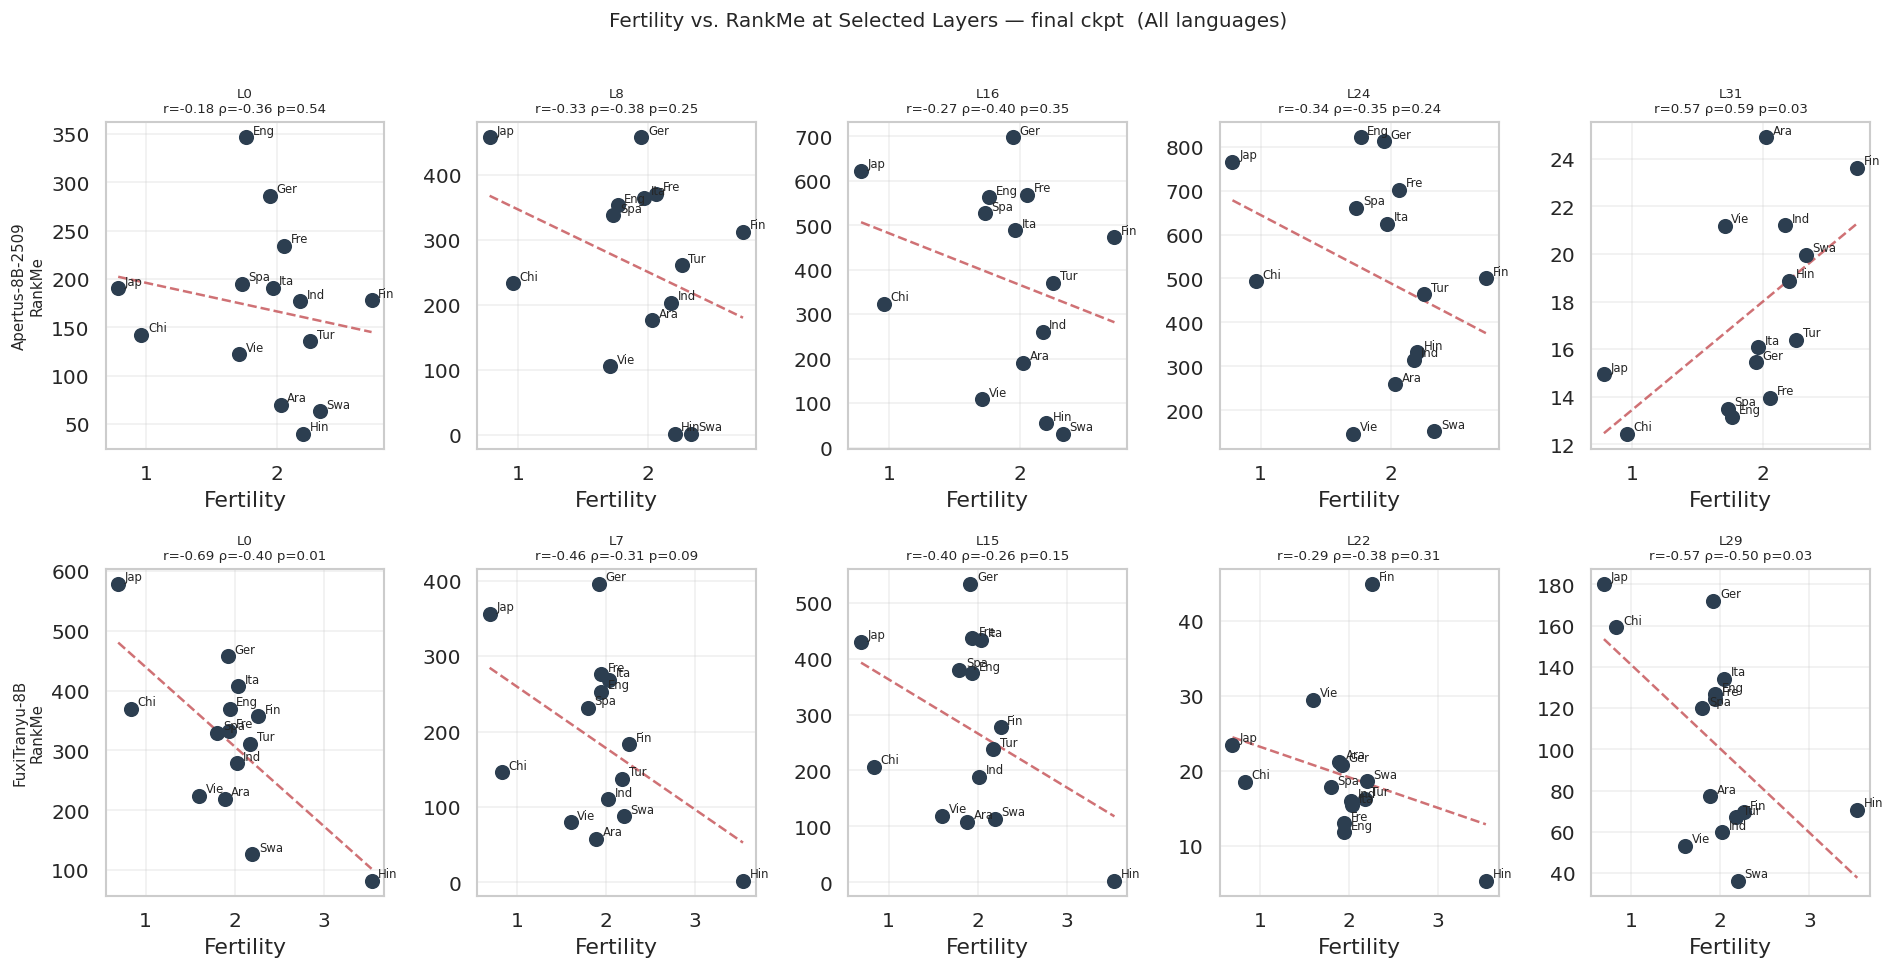

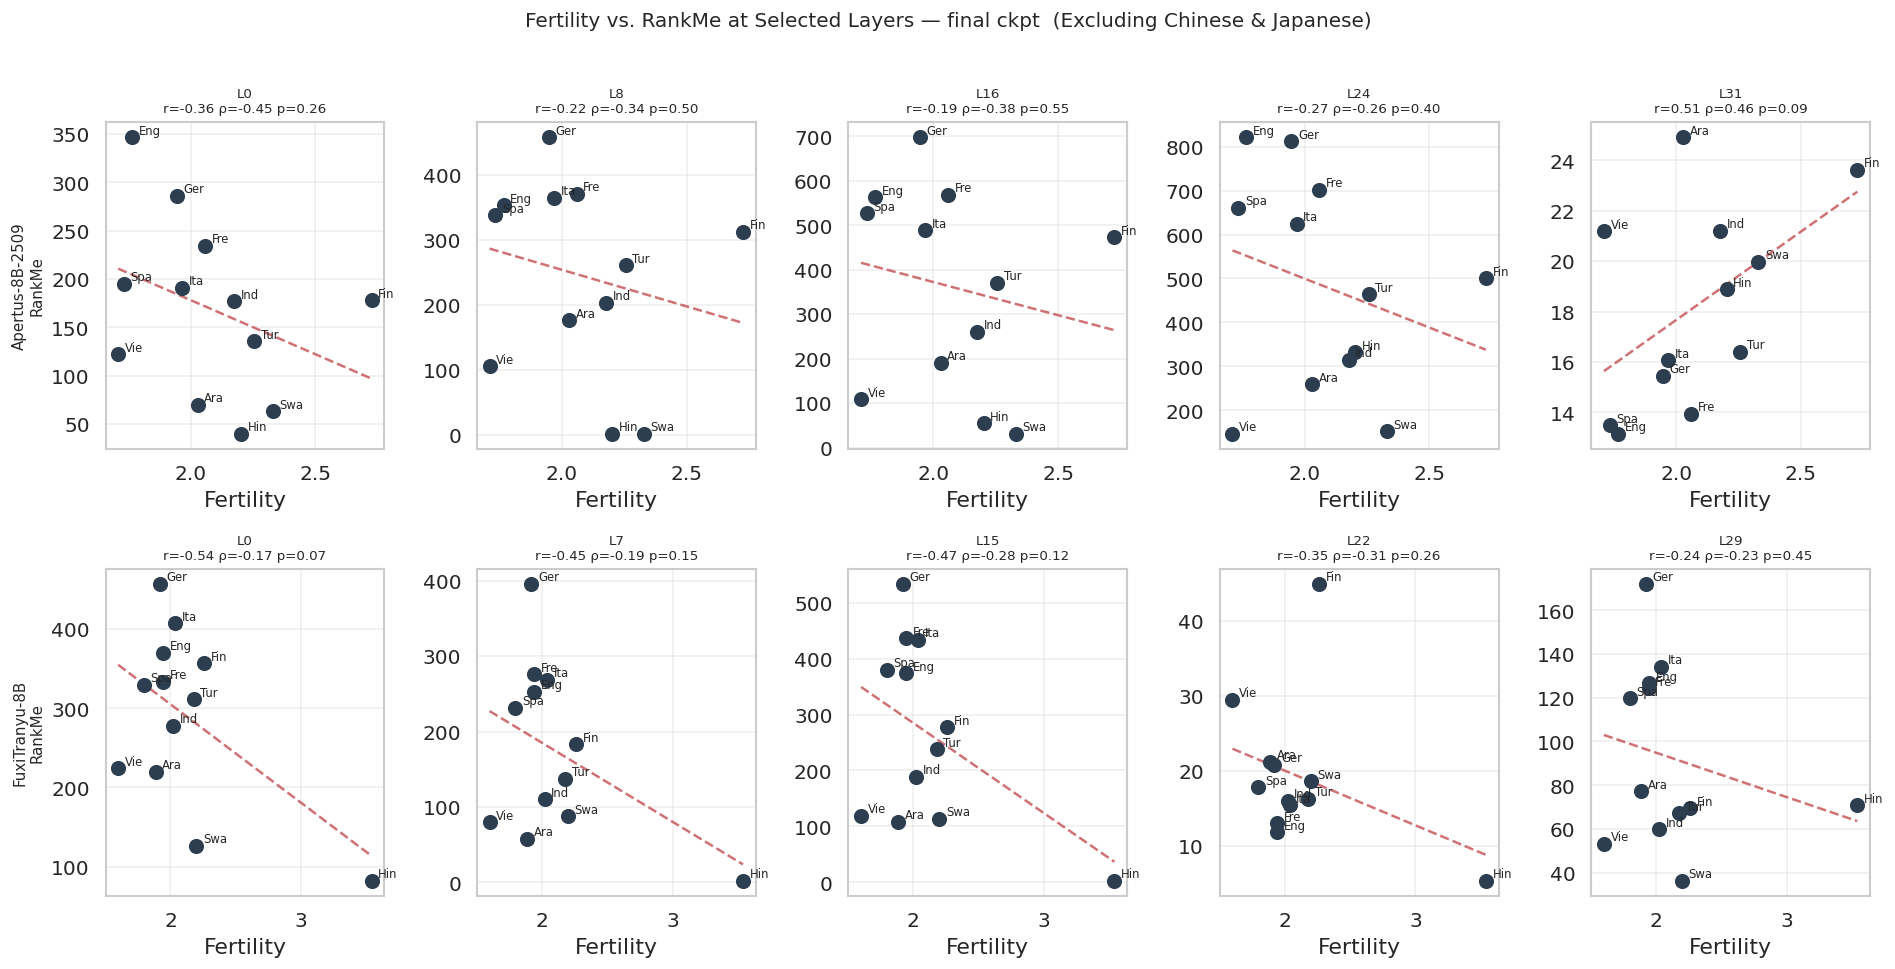

In [12]:
CJK_LANGS = {"Chinese", "Japanese"}
n = len(layers)
sel_layers = [layers[0], layers[n // 4], layers[n // 2], layers[3 * n // 4], layers[-1]]

_mdata = [(MODEL_LABEL, df_final, fertility, common_langs, sel_layers)]
if df2 is not None:
    n2 = len(layers2)
    sel2 = [layers2[0], layers2[n2 // 4], layers2[n2 // 2], layers2[3 * n2 // 4], layers2[-1]]
    _mdata.append((COMPARE_LABEL, df2_final, fertility2, common_langs2, sel2))

for subset_label, excl, suffix in [
    ("All languages",                set(),      "_all"),
    ("Excluding Chinese & Japanese", CJK_LANGS,  "_no_cjk"),
]:
    n_rows, n_cols = len(_mdata), 5
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = np.array(axes).reshape(n_rows, n_cols)

    for row, (label, df_fin, fert, c_langs, s_layers) in enumerate(_mdata):
        langs_sub = [l for l in c_langs if l not in excl and l in fert]
        for col, layer in enumerate(s_layers):
            ax = axes[row, col]
            sub = df_fin[df_fin.layer == layer]
            xs, ys, labs = [], [], []
            for lang in langs_sub:
                r = sub[sub.dataset == lang]
                if not r.empty:
                    xs.append(fert[lang]); ys.append(r.rankme.values[0]); labs.append(lang)
            xs, ys = np.array(xs), np.array(ys)
            if len(xs) < 3:
                ax.set_title(f"L{layer_num(layer)}\n(no data)", fontsize=9); continue
            r_val, p = pearsonr(xs, ys)
            rho, _   = spearmanr(xs, ys)
            ax.scatter(xs, ys, s=65, color="#2c3e50", zorder=3)
            for x, y, lab in zip(xs, ys, labs):
                ax.annotate(lab[:3], (x, y), xytext=(4, 2), textcoords="offset points", fontsize=7)
            z = np.polyfit(xs, ys, 1)
            xfit = np.linspace(xs.min(), xs.max(), 80)
            ax.plot(xfit, np.polyval(z, xfit), "r--", lw=1.5, alpha=0.8)
            ax.set_title(f"L{layer_num(layer)}\nr={r_val:.2f} ρ={rho:.2f} p={p:.2f}", fontsize=8)
            ax.set_xlabel("Fertility")
            if col == 0:
                ax.set_ylabel(f"{label}\nRankMe", fontsize=9)
            ax.grid(True, alpha=0.3)

    fig.suptitle(f"Fertility vs. RankMe at Selected Layers — final ckpt  ({subset_label})",
                 fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f"{STATIC_DIR}/scatter_fertility_rankme_{MODEL_LABEL}{suffix}.pdf", bbox_inches="tight")
    plt.show()

### 3b. Correlation Profile Across All Layers

The profile shows how tightly fertility and RankMe track each other as a function of depth.
Gold bands mark layers where Pearson $r$ is statistically significant at $p < 0.05$.
Both the full 14-language set and a CJK-excluded subset are shown.

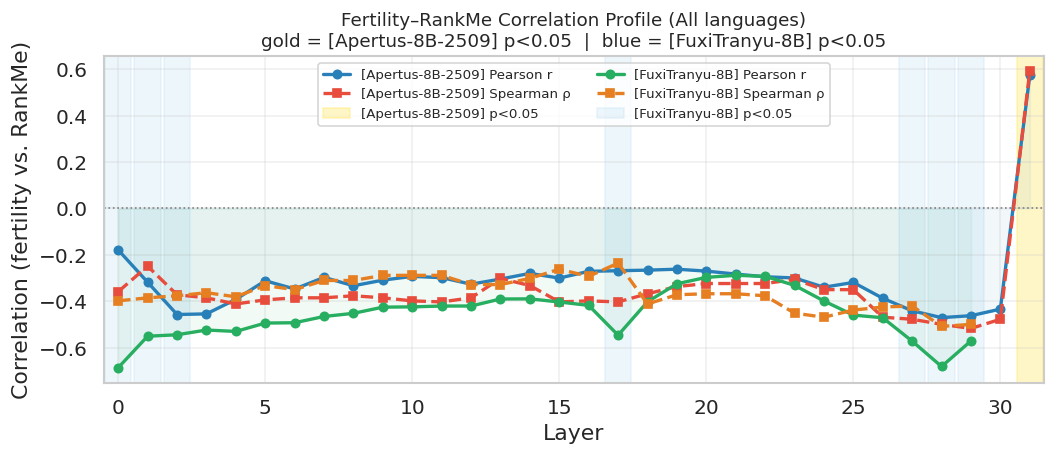


[All languages] Layers |r|>0.5 (Apertus-8B-2509):
 layer  pearson_r  spearman_rho  p_value
    31   0.572938      0.591209 0.032225


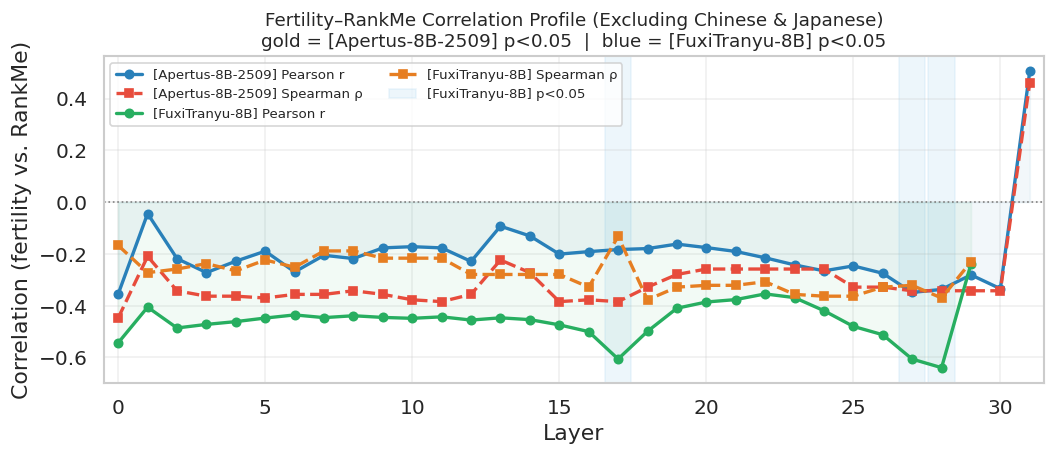


[Excluding Chinese & Japanese] Layers |r|>0.5 (Apertus-8B-2509):
 layer  pearson_r  spearman_rho  p_value
    31   0.505683      0.461538 0.093497


In [13]:
def _draw_corr_ax(ax, lnums, pr_list, rho_list, pv_list, label, ckpt, color_pr="#2980b9", color_rho="#e74c3c"):
    ax.plot(lnums, pr_list,  "o-",  color=color_pr,  lw=2, ms=5, label="Pearson r")
    ax.plot(lnums, rho_list, "s--", color=color_rho, lw=2, ms=5, label="Spearman ρ")
    ax.axhline(0, color="gray", lw=1, ls=":")
    ax.fill_between(lnums, pr_list, 0, alpha=0.08, color=color_pr)
    sig_added = False
    for lnum, p in zip(lnums, pv_list):
        if p is not None and not np.isnan(p) and p < 0.05:
            ax.axvspan(lnum - 0.45, lnum + 0.45, alpha=0.18, color="gold", zorder=0,
                       label="p<0.05" if not sig_added else None)
            sig_added = True
    ax.set_xlabel("Layer")
    ax.set_ylabel("Correlation (fertility vs. RankMe)")
    ax.set_title(f"[{label}]\nFertility–RankMe Correlation Profile\n"
                 f"{ckpt}  |  last-token  |  gold = p < 0.05", fontsize=11)
    ax.set_xlim(-0.5, lnums[-1] + 0.5)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

CJK_LANGS = {"Chinese", "Japanese"}

for subset_label, excl, suffix in [
    ("All languages",                set(),      "_all"),
    ("Excluding Chinese & Japanese", CJK_LANGS,  "_no_cjk"),
]:
    prs, rhos, pvals = [], [], []
    for layer in layers:
        sub = df_final[df_final.layer == layer]
        xs, ys = [], []
        for lang in [l for l in common_langs if l not in excl]:
            row = sub[sub.dataset == lang]
            if not row.empty:
                xs.append(fertility[lang]); ys.append(row.rankme.values[0])
        if len(xs) < 3:
            prs.append(np.nan); rhos.append(np.nan); pvals.append(np.nan); continue
        r, p = pearsonr(xs, ys); rho, _ = spearmanr(xs, ys)
        prs.append(r); rhos.append(rho); pvals.append(p)

    prs2, rhos2, pvals2 = [], [], []
    if df2 is not None and fertility2:
        for layer in layers2:
            sub = df2_final[df2_final.layer == layer]
            xs, ys = [], []
            for lang in [l for l in common_langs2 if l not in excl]:
                row = sub[sub.dataset == lang]
                if not row.empty:
                    xs.append(fertility2[lang]); ys.append(row.rankme.values[0])
            if len(xs) < 3:
                prs2.append(np.nan); rhos2.append(np.nan); pvals2.append(np.nan); continue
            r, p = pearsonr(xs, ys); rho, _ = spearmanr(xs, ys)
            prs2.append(r); rhos2.append(rho); pvals2.append(p)

    # ── Combined: both models overlaid on one axes ─────────────────────────
    fig, ax = plt.subplots(figsize=(9, 4))

    # Model 1 (blue / red lines, gold significance bands)
    ax.plot(layer_nums, prs,  "o-",  color="#2980b9", lw=2, ms=5, label=f"[{MODEL_LABEL}] Pearson r")
    ax.plot(layer_nums, rhos, "s--", color="#e74c3c", lw=2, ms=5, label=f"[{MODEL_LABEL}] Spearman ρ")
    ax.fill_between(layer_nums, prs, 0, alpha=0.06, color="#2980b9")
    sig1 = False
    for lnum, p in zip(layer_nums, pvals):
        if p is not None and not np.isnan(p) and p < 0.05:
            ax.axvspan(lnum - 0.45, lnum + 0.45, alpha=0.22, color="gold", zorder=0,
                       label=f"[{MODEL_LABEL}] p<0.05" if not sig1 else None)
            sig1 = True

    # Model 2 (green / orange lines, light-blue significance bands)
    if prs2:
        ax.plot(layer_nums2, prs2,  "o-",  color="#27ae60", lw=2, ms=5, label=f"[{COMPARE_LABEL}] Pearson r")
        ax.plot(layer_nums2, rhos2, "s--", color="#e67e22", lw=2, ms=5, label=f"[{COMPARE_LABEL}] Spearman ρ")
        ax.fill_between(layer_nums2, prs2, 0, alpha=0.06, color="#27ae60")
        sig2 = False
        for lnum, p in zip(layer_nums2, pvals2):
            if p is not None and not np.isnan(p) and p < 0.05:
                ax.axvspan(lnum - 0.45, lnum + 0.45, alpha=0.22, color="#aed6f1", zorder=0,
                           label=f"[{COMPARE_LABEL}] p<0.05" if not sig2 else None)
                sig2 = True
    elif df2 is not None:
        print(f"({COMPARE_LABEL} not shown — no fertility data loaded)")

    ax.axhline(0, color="gray", lw=1, ls=":")
    ax.set_xlabel("Layer")
    ax.set_ylabel("Correlation (fertility vs. RankMe)")
    all_lnums = layer_nums + (layer_nums2 if prs2 else [])
    ax.set_xlim(-0.5, max(all_lnums) + 0.5)
    band_note = (f"gold = [{MODEL_LABEL}] p<0.05  |  blue = [{COMPARE_LABEL}] p<0.05"
                 if prs2 else "gold = p<0.05")
    ax.set_title(f"Fertility–RankMe Correlation Profile ({subset_label})\n{band_note}", fontsize=11)
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{STATIC_DIR}/correlation_profile_combined{suffix}.pdf", bbox_inches="tight")
    plt.show()

    df_corr = pd.DataFrame({"layer": layer_nums, "pearson_r": prs, "spearman_rho": rhos, "p_value": pvals})
    print(f"\n[{subset_label}] Layers |r|>0.5 ({MODEL_LABEL}):")
    print(df_corr[df_corr.pearson_r.abs() > 0.5].to_string(index=False))

### Observations
Most layer correlations are not statistically significant ($p > 0.05$). For Apertus, the only statistically relevant correlation happens at the last layer, where the correlation becomes suddenly positive after being negative in all previous layers.
In Fuxi instead we observe a statistically relevant correlation on the first and last 3 layers, but the correlation is always negative.
A significant correlation early and late in the model makes sense, as these are the layers where the representation is still not too abstract and strictly linked to syntax/semantics. The difference in the correlation on the last layer between the two models is somewhat surprising and hard to justify.

## 4. Vocabulary Coverage-RankMe Correlation

Vocabulary coverage measures the *breadth* of the token vocabulary a language activates across a Wikipedia sample, whereas fertility measures *density* (tokens per word). Here we ask whether coverage is a better or complementary predictor of representational geometry.

We follow the same methodology as Section 3: scatter plots at five representative layers and a layer-by-layer Pearson $r$ / Spearman $\rho$ correlation profile, with gold bands indicating $p < 0.05$.

> **Note:** This section requires vocabulary coverage data computed in Section 1b.

### 4a. Scatter Plots at Selected Layers

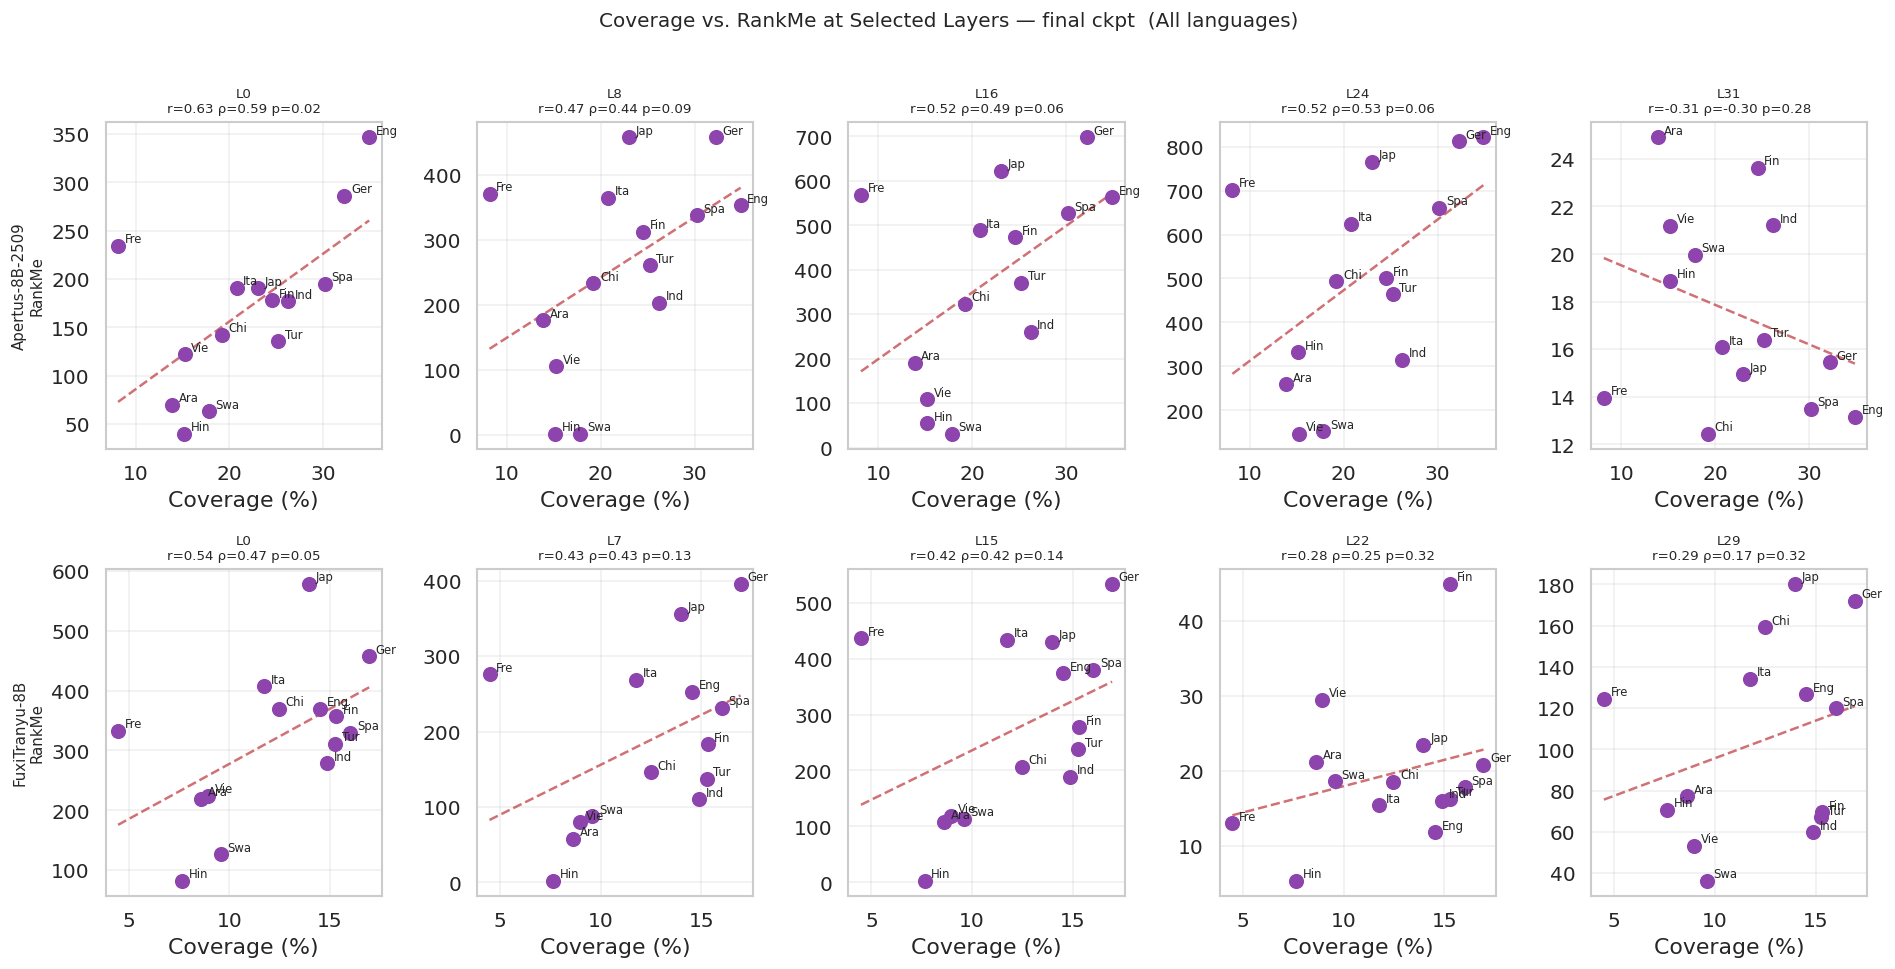

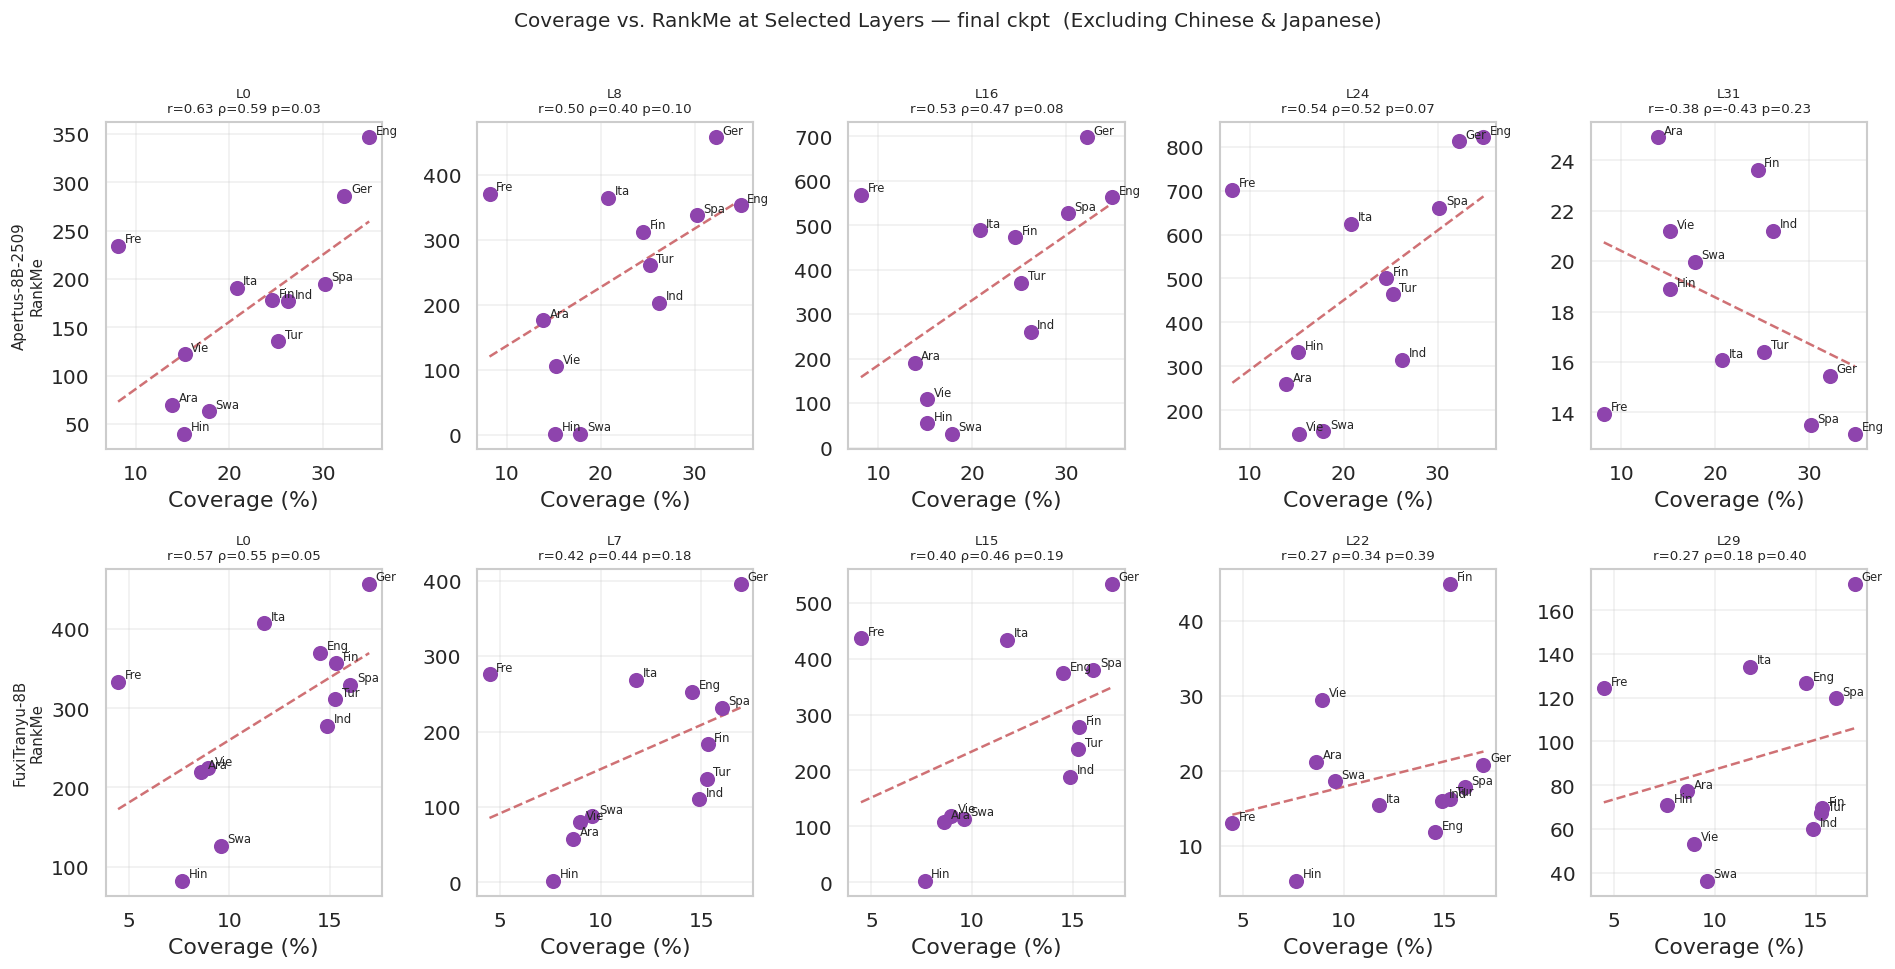

In [14]:
if not vocab_coverage_pct:
    print("No coverage data — run COMPUTE block.")
else:
    n_l = len(layers)
    sel_cov = [layers[0], layers[n_l // 4], layers[n_l // 2], layers[3 * n_l // 4], layers[-1]]
    CJK_LANGS = {"Chinese", "Japanese"}

    mdata_cov = [(MODEL_LABEL, df_final, vocab_coverage_pct, common_langs, sel_cov)]
    if df2 is not None and vocab_coverage_pct2:
        n_l2 = len(layers2)
        sel_cov2 = [layers2[0], layers2[n_l2 // 4], layers2[n_l2 // 2], layers2[3 * n_l2 // 4], layers2[-1]]
        mdata_cov.append((COMPARE_LABEL, df2_final, vocab_coverage_pct2, common_langs2, sel_cov2))

    for subset_label, excl, suffix in [
        ("All languages",                set(),      "_all"),
        ("Excluding Chinese & Japanese", CJK_LANGS,  "_no_cjk"),
    ]:
        n_rows, n_cols = len(mdata_cov), 5
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
        axes = np.array(axes).reshape(n_rows, n_cols)

        for row, (label, df_fin, cov_pct, c_langs, s_layers) in enumerate(mdata_cov):
            langs_sub = [l for l in c_langs if l not in excl and l in cov_pct]
            for col, layer in enumerate(s_layers):
                ax = axes[row, col]
                sub = df_fin[df_fin.layer == layer]
                xs, ys, labs = [], [], []
                for lang in langs_sub:
                    r = sub[sub.dataset == lang]
                    if not r.empty:
                        xs.append(cov_pct[lang]); ys.append(r.rankme.values[0]); labs.append(lang)
                xs, ys = np.array(xs), np.array(ys)
                if len(xs) < 3:
                    ax.set_title(f"L{layer_num(layer)}\n(no data)", fontsize=9); continue
                r_val, p = pearsonr(xs, ys)
                rho, _   = spearmanr(xs, ys)
                ax.scatter(xs, ys, s=65, color="#8e44ad", zorder=3)
                for x, y, lab in zip(xs, ys, labs):
                    ax.annotate(lab[:3], (x, y), xytext=(4, 2), textcoords="offset points", fontsize=7)
                z = np.polyfit(xs, ys, 1)
                xfit = np.linspace(xs.min(), xs.max(), 80)
                ax.plot(xfit, np.polyval(z, xfit), "r--", lw=1.5, alpha=0.8)
                ax.set_title(f"L{layer_num(layer)}\nr={r_val:.2f} ρ={rho:.2f} p={p:.2f}", fontsize=8)
                ax.set_xlabel("Coverage (%)")
                if col == 0:
                    ax.set_ylabel(f"{label}\nRankMe", fontsize=9)
                ax.grid(True, alpha=0.3)

        fig.suptitle(f"Coverage vs. RankMe at Selected Layers — final ckpt  ({subset_label})",
                     fontsize=12, y=1.01)
        plt.tight_layout()
        plt.savefig(f"{STATIC_DIR}/scatter_coverage_rankme_{MODEL_LABEL}{suffix}.pdf", bbox_inches="tight")
        plt.show()

### 4b. Correlation Profile Across All Layers

Gold bands mark layers where Pearson $r$ is statistically significant at $p < 0.05$.

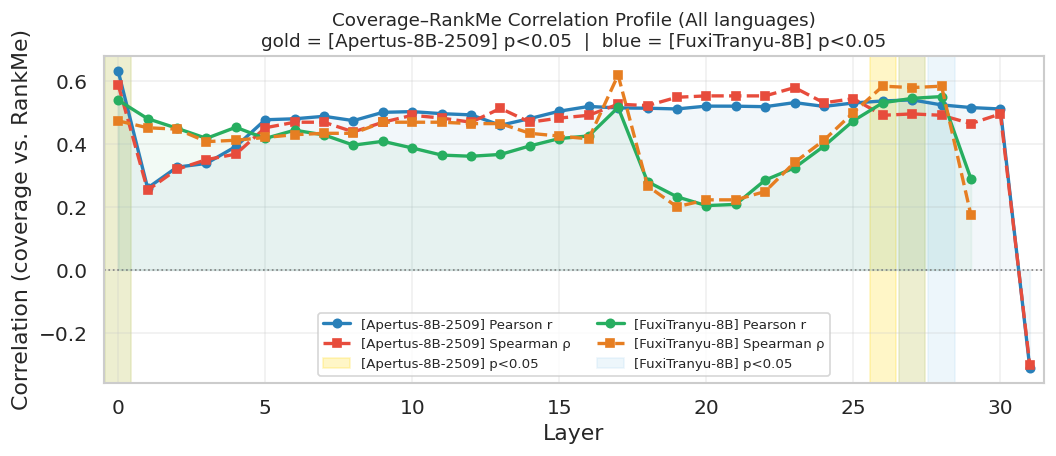

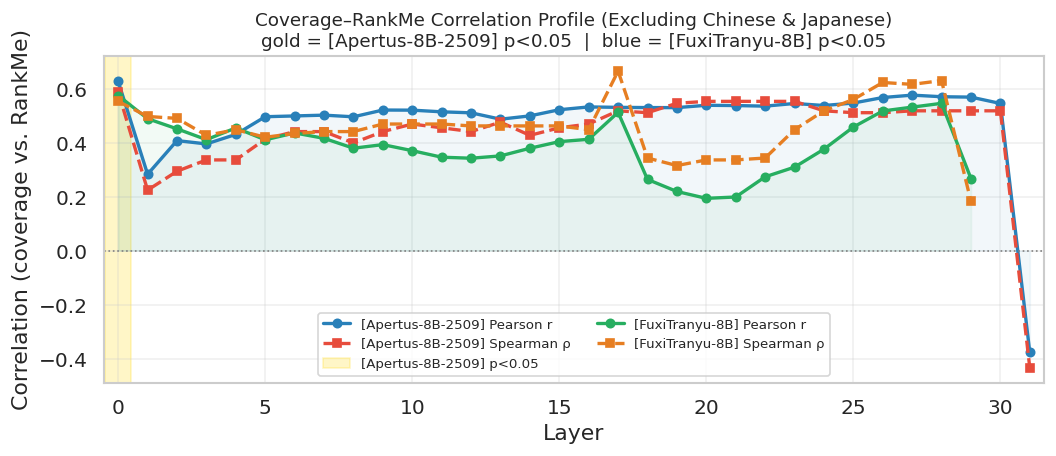

Layers |r|>0.5 (Apertus-8B-2509, coverage vs. RankMe):
 layer  pearson_r  spearman_rho  p_value
     0   0.626112      0.587413 0.029401
     7   0.501427      0.440559 0.096748
     9   0.520367      0.440559 0.082845
    10   0.519909      0.468531 0.083164
    11   0.513745      0.454545 0.087541
    12   0.510062      0.440559 0.090229
    15   0.521455      0.454545 0.082090
    16   0.531890      0.468531 0.075088
    17   0.530293      0.517483 0.076132
    18   0.529473      0.510490 0.076672
    19   0.529315      0.545455 0.076776
    20   0.537940      0.552448 0.071221
    21   0.536952      0.552448 0.071843
    22   0.534770      0.552448 0.073230
    23   0.544671      0.552448 0.067082
    24   0.537118      0.517483 0.071738
    25   0.546240      0.510490 0.066143
    26   0.566648      0.510490 0.054730
    27   0.575529      0.517483 0.050223
    28   0.569645      0.517483 0.053179
    29   0.568187      0.517483 0.053930
    30   0.544765      0.517483 0.067026


In [15]:
if not vocab_coverage_pct:
    print("No coverage data — run COMPUTE block.")
else:
    CJK_LANGS = {"Chinese", "Japanese"}
    has_cov2 = df2 is not None and bool(vocab_coverage_pct2)

    for subset_label, excl, suffix in [
        ("All languages",                set(),      "_all"),
        ("Excluding Chinese & Japanese", CJK_LANGS,  "_no_cjk"),
    ]:
        cov_prs, cov_rhos_all, cov_pvals = [], [], []
        for layer in layers:
            sub = df_final[df_final.layer == layer]
            xs_c, ys_r = [], []
            for lang in [l for l in common_langs if l in vocab_coverage_pct and l not in excl]:
                row = sub[sub.dataset == lang]
                if not row.empty:
                    xs_c.append(vocab_coverage_pct[lang]); ys_r.append(row.rankme.values[0])
            if len(xs_c) < 3:
                cov_prs.append(np.nan); cov_rhos_all.append(np.nan); cov_pvals.append(np.nan); continue
            r_c, p_c = pearsonr(xs_c, ys_r); rho_c, _ = spearmanr(xs_c, ys_r)
            cov_prs.append(r_c); cov_rhos_all.append(rho_c); cov_pvals.append(p_c)

        cov_prs2, cov_rhos2_all, cov_pvals2 = [], [], []
        if has_cov2:
            for layer in layers2:
                sub = df2_final[df2_final.layer == layer]
                xs_c, ys_r = [], []
                for lang in [l for l in common_langs2 if l in vocab_coverage_pct2 and l not in excl]:
                    row = sub[sub.dataset == lang]
                    if not row.empty:
                        xs_c.append(vocab_coverage_pct2[lang]); ys_r.append(row.rankme.values[0])
                if len(xs_c) < 3:
                    cov_prs2.append(np.nan); cov_rhos2_all.append(np.nan); cov_pvals2.append(np.nan); continue
                r_c, p_c = pearsonr(xs_c, ys_r); rho_c, _ = spearmanr(xs_c, ys_r)
                cov_prs2.append(r_c); cov_rhos2_all.append(rho_c); cov_pvals2.append(p_c)

        # ── Combined: both models overlaid on one axes ─────────────────────
        fig, ax = plt.subplots(figsize=(9, 4))

        # Model 1 (blue / red lines, gold significance bands)
        ax.plot(layer_nums, cov_prs,      "o-",  color="#2980b9", lw=2, ms=5, label=f"[{MODEL_LABEL}] Pearson r")
        ax.plot(layer_nums, cov_rhos_all, "s--", color="#e74c3c", lw=2, ms=5, label=f"[{MODEL_LABEL}] Spearman ρ")
        ax.fill_between(layer_nums, cov_prs, 0, alpha=0.06, color="#2980b9")
        sig1 = False
        for lnum, p in zip(layer_nums, cov_pvals):
            if p is not None and not np.isnan(p) and p < 0.05:
                ax.axvspan(lnum - 0.45, lnum + 0.45, alpha=0.22, color="gold", zorder=0,
                           label=f"[{MODEL_LABEL}] p<0.05" if not sig1 else None)
                sig1 = True

        # Model 2 (green / orange lines, light-blue significance bands)
        if cov_prs2:
            ax.plot(layer_nums2, cov_prs2,      "o-",  color="#27ae60", lw=2, ms=5, label=f"[{COMPARE_LABEL}] Pearson r")
            ax.plot(layer_nums2, cov_rhos2_all, "s--", color="#e67e22", lw=2, ms=5, label=f"[{COMPARE_LABEL}] Spearman ρ")
            ax.fill_between(layer_nums2, cov_prs2, 0, alpha=0.06, color="#27ae60")
            sig2 = False
            for lnum, p in zip(layer_nums2, cov_pvals2):
                if p is not None and not np.isnan(p) and p < 0.05:
                    ax.axvspan(lnum - 0.45, lnum + 0.45, alpha=0.22, color="#aed6f1", zorder=0,
                               label=f"[{COMPARE_LABEL}] p<0.05" if not sig2 else None)
                    sig2 = True

        ax.axhline(0, color="gray", lw=1, ls=":")
        ax.set_xlabel("Layer")
        ax.set_ylabel("Correlation (coverage vs. RankMe)")
        all_lnums = layer_nums + (layer_nums2 if cov_prs2 else [])
        ax.set_xlim(-0.5, max(all_lnums) + 0.5)
        band_note = (f"gold = [{MODEL_LABEL}] p<0.05  |  blue = [{COMPARE_LABEL}] p<0.05"
                     if cov_prs2 else "gold = p<0.05")
        ax.set_title(f"Coverage–RankMe Correlation Profile ({subset_label})\n{band_note}", fontsize=11)
        ax.legend(fontsize=8, ncol=2)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f"{STATIC_DIR}/coverage_corr_profile_combined{suffix}.pdf", bbox_inches="tight")
        plt.show()

    df_cov_corr = pd.DataFrame({
        "layer": layer_nums, "pearson_r": cov_prs,
        "spearman_rho": cov_rhos_all, "p_value": cov_pvals,
    })
    print(f"Layers |r|>0.5 ({MODEL_LABEL}, coverage vs. RankMe):")
    print(df_cov_corr[df_cov_corr.pearson_r.abs() > 0.5].to_string(index=False))

### Observations

Overall, we observe a similar trend as the one observed using fertility, just inverted. This is consistent, as a higher fertility generally means that the language is less represented, and therefore it will correspond to less coverage in the vocabulary. Again, the only significant correlations are observed near the two extremes of the models (first and last layers), indicating that the inner representations are highly more abstract and partially lose their dependence from tokenizaztion choices.

## 5. Training Dynamics by Fertility and Coverage Tier

We split the languages into three equal-sized tiers (low / medium / high) first by **fertility** and then by **vocabulary coverage**, and track mean RankMe over training at the **middle layer** — the depth where the most active learning of linguistic structure typically occurs.

A widening gap between tiers during training would confirm H3: the model learns more effective representations for low-fertility (or high-coverage) languages more quickly.

In [ ]:
df_fert_sorted = df_fert[df_fert.language.isin(common_langs)].sort_values("fertility").reset_index(drop=True)
k = max(1, len(df_fert_sorted) // 3)
low_tier  = df_fert_sorted.iloc[:k].language.tolist()
mid_tier  = df_fert_sorted.iloc[k:2*k].language.tolist()
high_tier = df_fert_sorted.iloc[2*k:].language.tolist()
print("Low:", low_tier, "  Mid:", mid_tier, "  High:", high_tier)

TIERS1 = {"Low": (low_tier, "#2980b9"), "Medium": (mid_tier, "#27ae60"), "High": (high_tier, "#e74c3c")}

def _tier_plot(ax, label, df_l, lyrs, ckpts, ckpt_labs, tiers, kind="Fertility"):
    mid_layer = lyrs[len(lyrs) // 2]
    df_mid = df_l[df_l.layer == mid_layer]
    for tname, (langs, color) in tiers.items():
        records = []
        for ci, ckpt in enumerate(ckpts):
            sub = df_mid[(df_mid.checkpoint == ckpt) & (df_mid.dataset.isin(langs))]
            if not sub.empty:
                records.append({"idx": ci, "mean": sub.rankme.mean(), "std": sub.rankme.std()})
        if not records: continue
        tr = pd.DataFrame(records).sort_values("idx")
        xs, ys = tr.idx.values, tr["mean"].values
        ax.plot(xs, ys, "o-", color=color, lw=2, ms=4, label=f"{tname} ({', '.join(langs)})")
        ax.fill_between(xs, ys - tr["std"].values, ys + tr["std"].values, alpha=0.12, color=color)
    ax.set_xticks(range(len(ckpts)))
    ax.set_xticklabels(ckpt_labs, rotation=45, ha="right", fontsize=7)
    ax.set_xlabel("Checkpoint (tokens seen)"); ax.set_ylabel("RankMe (mean ± std)")
    ax.set_title(f"[{label}] Training Dynamics by {kind} Tier\nlayer {layer_num(mid_layer)} | last-token", fontsize=11)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

# ── Fertility tiers ───────────────────────────────────────────────────────────
n_cols = 2 if (df2 is not None and df_fert2 is not None) else 1
fig, axes = plt.subplots(1, n_cols, figsize=(14 * n_cols, 5))
axes = [axes] if n_cols == 1 else list(axes)
_tier_plot(axes[0], MODEL_LABEL, df_last, layers, checkpoints, ckpt_labels, TIERS1)

if n_cols == 2:
    df_f2s = df_fert2[df_fert2.language.isin(common_langs2)].sort_values("fertility").reset_index(drop=True)
    k2 = max(1, len(df_f2s) // 3)
    TIERS2 = {
        "Low":    (df_f2s.iloc[:k2].language.tolist(),     "#2980b9"),
        "Medium": (df_f2s.iloc[k2:2*k2].language.tolist(), "#27ae60"),
        "High":   (df_f2s.iloc[2*k2:].language.tolist(),   "#e74c3c"),
    }
    _tier_plot(axes[1], COMPARE_LABEL, df2_last, layers2, checkpoints2, ckpt_labels2, TIERS2)

plt.tight_layout()
plt.savefig(f"{STATIC_DIR}/training_dynamics_{MODEL_LABEL}.pdf", bbox_inches="tight")
plt.show()

# ── Coverage tiers ────────────────────────────────────────────────────────────
if vocab_coverage_pct:
    cov_sorted1 = sorted([l for l in common_langs if l in vocab_coverage_pct], key=lambda l: vocab_coverage_pct[l])
    kc = max(1, len(cov_sorted1) // 3)
    COV_TIERS1 = {
        "Low":    (cov_sorted1[:kc],      "#2980b9"),
        "Medium": (cov_sorted1[kc:2*kc],  "#27ae60"),
        "High":   (cov_sorted1[2*kc:],    "#e74c3c"),
    }
    print("Coverage tiers — Low:", COV_TIERS1["Low"][0],
          "  Mid:", COV_TIERS1["Medium"][0], "  High:", COV_TIERS1["High"][0])

    has_cov2_tier = df2 is not None and bool(vocab_coverage_pct2)
    n_cols_cov = 2 if has_cov2_tier else 1
    fig, axes = plt.subplots(1, n_cols_cov, figsize=(14 * n_cols_cov, 5))
    axes = [axes] if n_cols_cov == 1 else list(axes)
    _tier_plot(axes[0], MODEL_LABEL, df_last, layers, checkpoints, ckpt_labels, COV_TIERS1, kind="Coverage")

    if has_cov2_tier:
        cov_sorted2 = sorted([l for l in common_langs2 if l in vocab_coverage_pct2], key=lambda l: vocab_coverage_pct2[l])
        kc2 = max(1, len(cov_sorted2) // 3)
        COV_TIERS2 = {
            "Low":    (cov_sorted2[:kc2],       "#2980b9"),
            "Medium": (cov_sorted2[kc2:2*kc2],  "#27ae60"),
            "High":   (cov_sorted2[2*kc2:],     "#e74c3c"),
        }
        _tier_plot(axes[1], COMPARE_LABEL, df2_last, layers2, checkpoints2, ckpt_labels2, COV_TIERS2, kind="Coverage")

    plt.tight_layout()
    plt.savefig(f"{STATIC_DIR}/training_dynamics_coverage_{MODEL_LABEL}.pdf", bbox_inches="tight")
    plt.show()

## Observations
To investigate whether RankMe evolution during training correlates with token fertility at a macro level, we categorized the languages into three distinct groups: low, medium, and high fertility. Interestingly, across both models, high-fertility languages consistently maintain the lowest RankMe scores throughout the entire training trajectory. However, this pattern does not hold linearly for the remaining groups: medium-fertility languages exhibit higher RankMe scores than low-fertility ones in Apertus, while their trajectories roughly overlap in Fuxi. Collectively, these macro-group dynamics mirror our per-language findings, confirming that token fertility does not reliably correlate with RankMe metrics.

### 5b. Spearman ρ Heatmap — All Checkpoints × All Layers

Each cell shows the Spearman rank correlation between the tokenization metric and RankMe across the languages for a given (checkpoint, layer) pair. Two heatmaps are produced: one for **fertility** and one for **vocabulary coverage**.

- **Blue**: higher value → lower RankMe (fragmented tokens / low coverage leads to more degenerate geometry)  
- **Red**: higher value → higher RankMe (model compensates with richer representations)  
- **White**: no correlation

This view reveals *when* and *where* in the network the tokenization signal emerges during training.

In [ ]:
def _rho_mat(df_l, fert, langs, ckpts, lyrs):
    mat = np.full((len(ckpts), len(lyrs)), np.nan)
    for ci, ckpt in enumerate(ckpts):
        for li, layer in enumerate(lyrs):
            sub = df_l[(df_l.checkpoint == ckpt) & (df_l.layer == layer)]
            xs, ys = [], []
            for lang in langs:
                row = sub[sub.dataset == lang]
                if not row.empty:
                    xs.append(fert[lang]); ys.append(row.rankme.values[0])
            if len(xs) >= 3:
                rho, _ = spearmanr(xs, ys); mat[ci, li] = rho
    return mat

def _plot_heatmap(panels, title_suffix, save_path):
    max_ckpts = max(len(p[1]) for p in panels)
    fig, axes = plt.subplots(1, len(panels), figsize=(14 * len(panels), max(5, max_ckpts * 0.22)))
    axes = [axes] if len(panels) == 1 else list(axes)
    for ax, (mat, ckpt_labs, lnums, label) in zip(axes, panels):
        xtick_pos  = list(range(0, len(lnums), max(1, len(lnums) // 8)))
        xtick_labs = [lnums[i] for i in xtick_pos]
        im = ax.imshow(mat, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest")
        plt.colorbar(im, ax=ax, label="Spearman ρ", shrink=0.8)
        ax.set_xticks(xtick_pos); ax.set_xticklabels(xtick_labs, fontsize=9)
        ax.set_yticks(range(len(ckpt_labs))); ax.set_yticklabels(ckpt_labs, fontsize=6)
        ax.set_xlabel("Layer"); ax.set_ylabel("Checkpoint")
        ax.set_title(
            f"[{label}] Spearman ρ — {title_suffix}\n"
            f"Blue: → lower RankMe  |  Red: → higher RankMe",
            fontsize=11)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

# ── Fertility heatmap ─────────────────────────────────────────────────────────
mat1 = _rho_mat(df_last, fertility, [l for l in common_langs if l in fertility],
                checkpoints, layers)
mat2 = None
if df2 is not None and fertility2:
    mat2 = _rho_mat(df2_last, fertility2, [l for l in common_langs2 if l in fertility2],
                    checkpoints2, layers2)

panels_fert = [(mat1, ckpt_labels, layer_nums, MODEL_LABEL)]
if mat2 is not None:
    panels_fert.append((mat2, ckpt_labels2, layer_nums2, COMPARE_LABEL))

_plot_heatmap(panels_fert, "Fertility vs. RankMe",
              f"{STATIC_DIR}/spearman_heatmap_{MODEL_LABEL}.pdf")

print(f"Mean ρ fertility ({MODEL_LABEL}): {np.nanmean(mat1):.3f}")
if mat2 is not None:
    print(f"Mean ρ fertility ({COMPARE_LABEL}): {np.nanmean(mat2):.3f}")

# ── Coverage heatmap ──────────────────────────────────────────────────────────
if vocab_coverage_pct:
    mat1_cov = _rho_mat(df_last, vocab_coverage_pct,
                        [l for l in common_langs if l in vocab_coverage_pct],
                        checkpoints, layers)
    mat2_cov = None
    if df2 is not None and vocab_coverage_pct2:
        mat2_cov = _rho_mat(df2_last, vocab_coverage_pct2,
                            [l for l in common_langs2 if l in vocab_coverage_pct2],
                            checkpoints2, layers2)

    panels_cov = [(mat1_cov, ckpt_labels, layer_nums, MODEL_LABEL)]
    if mat2_cov is not None:
        panels_cov.append((mat2_cov, ckpt_labels2, layer_nums2, COMPARE_LABEL))

    _plot_heatmap(panels_cov, "Coverage vs. RankMe",
                  f"{STATIC_DIR}/spearman_heatmap_coverage_{MODEL_LABEL}.pdf")

    print(f"Mean ρ coverage ({MODEL_LABEL}): {np.nanmean(mat1_cov):.3f}")
    if mat2_cov is not None:
        print(f"Mean ρ coverage ({COMPARE_LABEL}): {np.nanmean(mat2_cov):.3f}")

## 6. Conclusions

We revisit each hypothesis in light of the results.

---

### H1 - Layer-wise signature: fertility predicts RankMe at the final checkpoint, especially in late layers

**Partially supported, with a model-dependent direction.**

A statistically significant correlation between fertility and RankMe at the final checkpoint does appear in late layers, but the sign differs between models:

- **FuxiTranyu-8B**: significant negative correlations ($p < 0.05$) at both the first few and last few layers. The results show that high fertility is associated with *lower* RankMe, consistent with the hypothesis that tokenization inefficiency reduces representational diversity.
- **Apertus-8B-2509**: the only significant correlation emerges at the very last layer, and it is *positive*: this observation is hard to justify and may reflect noise or a model-specific architectural choice near the output projection.

In both cases, the majority of layers show no significant correlation, so the evidence for H1 is weak and inconsistent in sign.

---

### H2 - Depth profile: the fertility-RankMe correlation changes across depth

**Supported for both models.**

The correlation is clearly not constant across layers. FuxiTranyu-8B shows a distinct U-shaped pattern: significant correlation at the extremes (layers close to the embedding and output spaces) and near-zero correlation in the middle layers. This is consistent with the proposed mechanism, since early layers still operate close to the token surface where tokenization effects are most direct, middle layers learn more abstract, language-agnostic features, and the final layers, which project back toward the vocabulary, recover the tokenization signal.

Apertus-8B-2509 shows a weaker version of the same structure: the correlation is close to zero across most of the network and shifts sharply only at the last layer. Taken together, the depth-dependent pattern is the most robust finding in this analysis.

---

### H3 - Training trajectory: high- and low-fertility languages follow different RankMe growth curves

**Partially supported at the macro level; the strict tier ordering does not hold.**

Grouping languages into low, medium, and high fertility tiers reveals that **high-fertility languages consistently exhibit the lowest RankMe scores throughout the entire training trajectory** in both models. This is directionally consistent with H3.

However, the ordering breaks down between the low and medium tiers: in Apertus, medium-fertility languages reach higher RankMe than low-fertility ones, while in FuxiTranyu the two groups largely overlap. More critically, the gap between tiers does not widen as training progresses, as one would expect: there is no evidence that the model learns richer representations for low-fertility languages *faster*, only that the final geometry is somewhat different across tiers.

H3 is therefore confirmed in its weakest form (tier separation exists) but not in the stronger form (the separation grows with training).

---

### Overall

The main finding is that **tokenizer fertility has, at best, a weak and layer-dependent association with representational geometry**. The effect is most visible at the extremes of the network depth and is negative in direction (higher fragmentation yields lower effective rank) for FuxiTranyu-8B, but this pattern is not replicated in Apertus. Given the small number of languages (14) and models (2), none of the individual correlations are robust enough to support strong conclusions. The analysis should be read as exploratory: it identifies the network extremes as the most promising locus for future investigation, and motivates studying more models and languages before drawing generalizable claims.